<a href="https://colab.research.google.com/github/MostaryKhatun/Bioinformatrics_Thesis/blob/main/WGCNA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step1

In [ ]:
# Colab: Python cell
!pip -q install rpy2 pandas==2.2.2 matplotlib

# Enable R in Colab
import os, warnings
os.environ["R_HOME"] = "/usr/lib/R"


step2

In [ ]:
# Colab: Python cell – install R packages used by WGCNA
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
ro.r('''
options(warn=-1)
if (!require("BiocManager", quietly=TRUE)) install.packages("BiocManager", repos="https://cloud.r-project.org")
packs <- c("WGCNA","flashClust","dynamicTreeCut","pheatmap","VennDiagram","ggplot2","data.table")
for (p in packs) {
  if (!require(p, character.only=TRUE)) {
    if (p %in% rownames(installed.packages())) next
    tryCatch({
      BiocManager::install(p, ask=FALSE, update=FALSE)
    }, error=function(e) install.packages(p, repos="https://cloud.r-project.org"))
    library(p, character.only=TRUE)
  }
}
options(stringsAsFactors=FALSE)
allowWGCNAThreads()
''')






Attaching package: ‘fastcluster’



    hclust



Attaching package: ‘WGCNA’



    cor



Attaching package: ‘flashClust’



    hclust



    hclust











Allowing multi-threading with up to 2 threads.


step3

In [ ]:
# Colab: Python cell – upload files
from google.colab import files
up = files.upload()  # Upload the two CSVs
list(up.keys())


TypeError: 'NoneType' object is not subscriptable

step4

In [ ]:
# Colab: Python cell
import pandas as pd
import numpy as np

LABEL_COL = "label"   # <-- change if your phenotype column is named differently

COMMON_GENES = [
"TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R",
"GALNT11","HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2"
]

HUB_TABLE = pd.DataFrame({
    "Name":["IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3"],
    "Score":[59,21,13,9,2,2,2,2,2,2]
})

def load_matrix(path):
    """
    Reads a CSV where rows=samples and columns=genes (+ one label column).
    Returns (X, y), where:
      X: dataframe (samples x genes), numeric
      y: Series with 0/1 trait
    """
    df = pd.read_csv(path)
    # Try to locate label column robustly
    labcol = LABEL_COL if LABEL_COL in df.columns else (
        "Label" if "Label" in df.columns else
        "class" if "class" in df.columns else
        "Class" if "Class" in df.columns else None
    )
    if labcol is None:
        raise ValueError("Couldn't find a label column. Please set LABEL_COL to your label name.")
    y_raw = df[labcol].astype(str)
    # Map to 0/1 automatically
    if set(y_raw.unique()) <= {"0","1"}:
        y = y_raw.astype(int)
    else:
        # map first unique to 0, second to 1 (Control/Case)
        u = list(y_raw.unique())
        mapping = {u[0]:0, u[1]:1}
        y = y_raw.map(mapping)
    X = df.drop(columns=[labcol]).copy()
    # Keep only numeric
    X = X.apply(pd.to_numeric, errors="coerce")
    # Remove all-NA cols
    X = X.dropna(axis=1, how="all")
    # Fill residual NAs with column medians
    X = X.apply(lambda c: c.fillna(c.median()), axis=0)
    return X, y

def to_r_df(df, name):
    """Send a pandas dataframe to R with the given symbol name."""
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    pandas2ri.activate()
    ro.globalenv[name] = pandas2ri.py2rpy(df)


Run the full WGCNA pipeline (wrapped so you can reuse for both datasets)

In [ ]:
# Colab: Python cell
import textwrap
import rpy2.robjects as ro

WGCNA_R = ro.r("""
run_wgcna <- function(expr_df, trait_vec, dataset_name="dataset") {
  suppressPackageStartupMessages({
    library(WGCNA); library(dynamicTreeCut); library(flashClust)
    library(pheatmap); library(VennDiagram); library(ggplot2)
  })
  options(stringsAsFactors=FALSE)
  datExpr <- expr_df   # rows=samples, cols=genes

  # === A) Sample clustering dendrogram ===
  pdf(paste0(dataset_name,"_A_sample_dendrogram.pdf"), width=10, height=6)
  sampleTree <- hclust(dist(datExpr), method="average")
  par(cex=0.6); plot(sampleTree, main=paste(dataset_name,"- Sample clustering"), sub="", xlab="")
  dev.off()

  # === C) pickSoftThreshold plots ===
  powers = c(c(1:10), seq(from=12, to=30, by=2))
  sft <- pickSoftThreshold(datExpr, powerVector=powers, verbose=5, networkType="signed")
  chosenPower <- ifelse(is.na(sft$powerEstimate), 6, sft$powerEstimate)
  pdf(paste0(dataset_name,"_C_softThreshold.pdf"), width=12, height=5)
  par(mfrow=c(1,2))
  plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
       xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit, signed R^2",
       type="n", main="Scale independence")
  text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
       labels=powers, cex=0.9)
  abline(h=0.8, col="red")
  plot(sft$fitIndices[,1], sft$fitIndices[,5],
       xlab="Soft Threshold (power)", ylab="Mean connectivity", type="n", main="Mean connectivity")
  text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers, cex=0.9)
  dev.off()

  # === B) Network construction + module detection ===
  net <- blockwiseModules(
    datExpr, power=chosenPower, TOMType="signed", minModuleSize=30,
    reassignThreshold=0, mergeCutHeight=0.25, numericLabels=TRUE, pamRespectsDendro=FALSE,
    saveTOMs=FALSE, verbose=3
  )
  MEs <- net$MEs; moduleLabels <- net$colors; moduleColors <- labels2colors(moduleLabels)
  geneTree <- net$dendrograms[[1]]

  pdf(paste0(dataset_name,"_B_gene_dendro_modules.pdf"), width=12, height=6)
  plotDendroAndColors(geneTree, moduleColors[net$blockGenes[[1]]],
                      "Module colors", dendroLabels=FALSE, hang=0.03,
                      addGuide=TRUE, guideHang=0.05, main=paste(dataset_name,"- Gene dendrogram & modules"))
  dev.off()

  # === D) Module–trait relationships ===
  datTraits <- data.frame(Trait=as.numeric(trait_vec)) # 0/1
  MEs0 <- orderMEs(MEs)
  modTraitCor <- cor(MEs0, datTraits$Trait, use="p")
  modTraitP   <- corPvalueStudent(modTraitCor, nrow(datExpr))

  # heatmap
  textMatrix <- paste(signif(modTraitCor,2), "\n(", signif(modTraitP,1), ")", sep="")
  dim(textMatrix) <- dim(modTraitCor)
  pdf(paste0(dataset_name,"_D_module_trait_heatmap.pdf"), width=12, height=6)
  labeledHeatmap(Matrix=t(modTraitCor),
                 yLabels=names(MEs0), xLabels="Trait (0/1)",
                 ySymbols=names(MEs0), colorLabels=FALSE, colors=blueWhiteRed(50),
                 textMatrix=t(textMatrix), setStdMargins=FALSE, cex.text=0.8,
                 zlim=c(-1,1), main=paste(dataset_name,"- Module–trait relationships"))
  dev.off()

  # Collect outputs for Python side
  res <- list(
    chosenPower=chosenPower,
    moduleColors=moduleColors,
    moduleLabels=moduleLabels,
    geneNames=colnames(datExpr),
    kWithin = intramodularConnectivity(
      adjacency(datExpr, power=chosenPower, type="signed"),
      moduleColors
    )$kWithin
  )
  return(res)
}
""")


Run WGCNA on each dataset and make all plots

In [ ]:
import pandas as pd
from rpy2.robjects import pandas2ri, r
import rpy2.robjects as ro
import os

pandas2ri.activate()

# ------------------ Helper functions ------------------
def load_matrix(expr_csv, labels_csv):
    # Force first column to string to avoid mixed type warning
    X = pd.read_csv(expr_csv, index_col=0, dtype=str, low_memory=False)
    y_df = pd.read_csv(labels_csv)
    y = y_df['Label']
    return X, y

def to_r_df(df, name):
    ro.globalenv[name] = pandas2ri.py2rpy(df)

# ------------------ File paths ------------------
dep_expr_csv = "/content/GSE98793_expression.csv"
dep_labels_csv = "/content/GSE98793_labels.csv"
str_expr_csv = "/content/GSE63878_expression.csv"
str_labels_csv = "/content/GSE63878_labels.csv"

# ------------------ Load data ------------------
X_dep, y_dep = load_matrix(dep_expr_csv, dep_labels_csv)
X_str, y_str = load_matrix(str_expr_csv, str_labels_csv)

to_r_df(X_dep, "expr_dep")
to_r_df(X_str, "expr_str")
to_r_df(pd.DataFrame({"Trait": y_dep.values}), "trait_dep_df")
to_r_df(pd.DataFrame({"Trait": y_str.values}), "trait_str_df")

# ------------------ Load WGCNA R function ------------------
# Make sure your run_wgcna.R is uploaded to /content
ro.r('source("/content/run_wgcna.R")')
run_wgcna = ro.globalenv["run_wgcna"]

# ------------------ Function to run WGCNA and save plots ------------------
def run_wgcna_save_plots(expr_r, trait_r, name_prefix="Depression", output_dir="/content/plots"):
    os.makedirs(output_dir, exist_ok=True)

    # PNG
    r.png(f"{output_dir}/{name_prefix}.png", width=1200, height=800, res=150)
    run_wgcna(expr_r, trait_r, name_prefix)
    r.dev_off()

    # JPEG
    r.jpeg(f"{output_dir}/{name_prefix}.jpeg", width=1200, height=800, res=150)
    run_wgcna(expr_r, trait_r, name_prefix)
    r.dev_off()

    # PDF
    r.pdf(f"{output_dir}/{name_prefix}.pdf", width=12, height=8)
    run_wgcna(expr_r, trait_r, name_prefix)
    r.dev_off()

# ------------------ Run WGCNA and save plots ------------------
run_wgcna_save_plots(r("as.data.frame(expr_dep)"), r("trait_dep_df$Trait"), "Depression")
run_wgcna_save_plots(r("as.data.frame(expr_str)"), r("trait_str_df$Trait"), "Stress")

print("All plots saved in /content/plots folder.")


  cannot open the connection


 



RRuntimeError: Error in file(filename, "r", encoding = encoding) : 
  cannot open the connection


In [ ]:
# ===============================================
# Colab-ready R script: WGCNA end-to-end + Hub validation
# Train:   GSE63878_expression.csv + GSE63878_labels.csv
# Test:    GSE98793_expression.csv + GSE98793_labels.csv
# Outputs: all plots saved as PNG and PDF into ./WGCNA_outputs
# Author: paste this whole cell into a Colab R notebook (or any R env)
# ===============================================

# -----------------------------
# 0) Setup & packages
# -----------------------------
options(stringsAsFactors = FALSE)

req_pkgs <- c(
  "WGCNA", "data.table", "ggplot2", "pheatmap", "VennDiagram", "limma", "pROC"
)
for (p in req_pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p, repos = "https://cloud.r-project.org")
  }
}

suppressPackageStartupMessages({
  library(WGCNA)
  library(data.table)
  library(ggplot2)
  library(pheatmap)
  library(VennDiagram)
  library(limma)
  library(pROC)
})

allowWGCNAThreads()

# Create output folder
OUTDIR <- "WGCNA_outputs"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR)

# Utility: save both PNG and PDF
save_plot_dual <- function(file_base, width = 10, height = 7) {
  png(paste0(OUTDIR, "/", file_base, ".png"), width = width, height = height, units = "in", res = 300)
  dev.control("inhibit")  # no-op placeholder; rely on caller to draw before dev.off()
}
end_save <- function(file_base, width = 10, height = 7) {
  dev.off()
  pdf(paste0(OUTDIR, "/", file_base, ".pdf"), width = width, height = height)
  dev.control("inhibit")
  dev.off()
}

# -----------------------------
# 1) File paths (edit if needed)
# -----------------------------
TRAIN_EXPR <- "/content/GSE63878_expression.csv"
TRAIN_LABEL<- "/content/GSE63878_labels.csv"
TEST_EXPR  <- "/content/GSE98793_expression.csv"
TEST_LABEL <- "/content/GSE98793_labels.csv"

# -----------------------------
# 2) Load data
#    Expect expression as: rows = genes, cols = samples
#    Labels: two cols: sample ID + group (case/control or 1/0). Flexible parsing included.
# -----------------------------
read_expr <- function(path) {
  dt <- fread(path)
  rn <- dt[[1]]
  dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(rn)
  m
}

read_labels <- function(path) {
  lab <- fread(path)
  cn <- tolower(names(lab))
  # heuristics for columns
  id_col <- which(cn %in% c("sample", "sampleid", "id", "geo_accession", "gsm", "name"))
  grp_col <- which(cn %in% c("group", "status", "phenotype", "class", "label", "casecontrol", "condition"))
  if (length(id_col) == 0) id_col <- 1
  if (length(grp_col) == 0) grp_col <- 2
  df <- data.frame(Sample = as.character(lab[[id_col[1]]]),
                   Group  = lab[[grp_col[1]]])
  # normalize group into 0/1 numeric
  if (is.character(df$Group) || is.factor(df$Group)) {
    g <- tolower(as.character(df$Group))
    if (all(g %in% c("case", "control"))) {
      df$Group <- ifelse(g == "case", 1, 0)
    } else if (all(g %in% c("patient", "healthy"))) {
      df$Group <- ifelse(g == "patient", 1, 0)
    } else {
      # try to coerce to numeric; fallback to factor 1/0
      sup <- suppressWarnings(as.numeric(g))
      if (all(!is.na(sup))) {
        df$Group <- sup
      } else {
        df$Group <- as.numeric(factor(g)) - 1  # make 0/1
      }
    }
  }
  df$Group <- as.numeric(df$Group)
  df
}

expr_train <- read_expr(TRAIN_EXPR)
lab_train  <- read_labels(TRAIN_LABEL)
expr_test  <- read_expr(TEST_EXPR)
lab_test   <- read_labels(TEST_LABEL)

# Align by intersecting samples
align_by_labels <- function(expr, lab) {
  common <- intersect(colnames(expr), lab$Sample)
  if (length(common) < 10) {
    stop("Too few overlapping samples between expression and labels. Check sample IDs.")
  }
  expr2 <- expr[, common, drop = FALSE]
  lab2  <- lab[match(common, lab$Sample), , drop = FALSE]
  list(expr = expr2, lab = lab2)
}

al_tr <- align_by_labels(expr_train, lab_train)
expr_train <- al_tr$expr
lab_train  <- al_tr$lab

al_te <- align_by_labels(expr_test, lab_test)
expr_test <- al_te$expr
lab_test  <- al_te$lab

# Ensure genes are rows, samples are cols for WGCNA we transpose
# WGCNA expects: rows = samples, cols = genes
make_wgcna_matrix <- function(expr) {
  datExpr <- as.data.frame(t(expr))
  # QC: remove genes/samples with too many missing values
  gsg <- goodSamplesGenes(datExpr, verbose = 3)
  if (!gsg$allOK) {
    datExpr <- datExpr[gsg$goodSamples, gsg$goodGenes]
  }
  datExpr
}

datExpr_train <- make_wgcna_matrix(expr_train)
rownames(datExpr_train) <- colnames(expr_train)  # samples

# -----------------------------
# 3) Sample clustering to detect outliers (Fig A)
# -----------------------------
save_plot_dual("A_sample_clustering", width = 12, height = 6)
  sampleTree <- hclust(dist(datExpr_train), method = "average")
  par(cex = 0.6, mar = c(0,4,2,0))
  plot(sampleTree, main = "Sample clustering to detect outliers", sub = "", xlab = "", cex.lab = 1.2)
end_save("A_sample_clustering", width = 12, height = 6)

# Optionally remove outlier samples by cutting tree (commented)
# cutHeight <- NA
# clust <- cutreeStatic(sampleTree, cutHeight = cutHeight, minSize = 10)
# keepSamples <- (clust == which.max(table(clust)))
# datExpr_train <- datExpr_train[keepSamples, ]
# lab_train <- lab_train[match(rownames(datExpr_train), lab_train$Sample),]

# -----------------------------
# 4) Choose soft-thresholding power (Fig C)
# -----------------------------
powers <- 1:20
sft <- pickSoftThreshold(datExpr_train, powerVector = powers, networkType = "signed", verbose = 5)

# Plot scale-free topology fit index as a function of the soft-threshold power
save_plot_dual("C_soft_threshold_ScaleIndependence", width = 10, height = 5)
  par(mfrow = c(1,2))
  plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
       xlab = "Soft Threshold (power)", ylab = "Scale Free Topology Model Fit,signed R^2",
       type = "n", main = "Scale independence")
  text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
       labels = powers, cex = 0.9)
  abline(h = 0.8, col = "red")
  plot(sft$fitIndices[,1], sft$fitIndices[,5],
       xlab = "Soft Threshold (power)", ylab = "Mean connectivity", type = "n", main = "Mean connectivity")
  text(sft$fitIndices[,1], sft$fitIndices[,5], labels = powers, cex = 0.9)
end_save("C_soft_threshold_ScaleIndependence", width = 10, height = 5)

softPower <- sft$powerEstimate
if (is.na(softPower)) {
  # Fallback if automatic estimate fails
  softPower <- 6
}

# -----------------------------
# 5) Network construction + module detection (Fig B)
# -----------------------------
net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = file.path(OUTDIR, "trainTOM"),
  verbose = 3
)

moduleColors <- labels2colors(net$colors)

save_plot_dual("B_cluster_dendrogram", width = 12, height = 6)
  plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]],
                      "Module colors",
                      dendroLabels = FALSE, hang = 0.03,
                      addGuide = TRUE, guideHang = 0.05,
                      main = "Cluster Dendrogram")
end_save("B_cluster_dendrogram", width = 12, height = 6)

# -----------------------------
# 6) Module–trait relationships (Fig D)
# -----------------------------
# Prepare trait dataframe matching samples
trait <- data.frame(row.names = lab_train$Sample, Trait = lab_train$Group)
trait <- trait[match(rownames(datExpr_train), rownames(trait)), , drop = FALSE]

MEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes
MEs  <- orderMEs(MEs0)

moduleTraitCor <- cor(MEs, trait$Trait, use = "p")
moduleTraitP   <- corPvalueStudent(moduleTraitCor, nrow(datExpr_train))

# Heatmap
textMatrix <- paste(signif(moduleTraitCor, 2), "\n(", signif(moduleTraitP, 1), ")", sep = "")
dim(textMatrix) <- dim(moduleTraitCor)

save_plot_dual("D_module_trait_relationships", width = 11, height = 9)
  par(mar = c(6, 8.5, 3, 3))
  labeledHeatmap(Matrix = moduleTraitCor,
                 xLabels = "Trait",
                 yLabels = names(MEs),
                 ySymbols = names(MEs),
                 colorLabels = FALSE,
                 colors = blueWhiteRed(50),
                 textMatrix = textMatrix,
                 setStdMargins = FALSE,
                 cex.text = 0.8,
                 zlim = c(-1,1),
                 main = paste("Module–trait relationships"))
end_save("D_module_trait_relationships", width = 11, height = 9)

# Identify the most associated module
bestModule <- names(which.max(abs(moduleTraitCor)))
cat("Most trait-associated module (by |cor|):", bestModule, "\n")

moduleColorOfBest <- gsub("ME", "", bestModule)
inBestModule <- moduleColors == moduleColorOfBest
bestModuleGenes <- colnames(datExpr_train)[inBestModule]
write.csv(bestModuleGenes, file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")), row.names = FALSE)

# Gene Significance (GS) vs Module Membership (kME)
MM <- as.data.frame(cor(datExpr_train, MEs, use = "p"))
GS <- as.data.frame(cor(datExpr_train, trait$Trait, use = "p"))
colnames(GS) <- "GS.Trait"

kME_col <- paste0("kME_", bestModule)
if (!kME_col %in% colnames(MM)) {
  # In some versions names are like MEblue. Align them
  names(MM) <- paste0("kME_", names(MM))
}

MM_best <- MM[[paste0("kME_", bestModule)]]

save_plot_dual("GS_vs_MM_bestModule", width = 8, height = 6)
  par(mfrow=c(1,1))
  plot(abs(MM_best[inBestModule]), abs(GS$GS.Trait[inBestModule]),
       xlab = paste("Module Membership in", moduleColorOfBest),
       ylab = "Gene Significance for Trait",
       main = "GS vs MM in best module")
  abline(lm(abs(GS$GS.Trait[inBestModule]) ~ abs(MM_best[inBestModule])), lty = 2)
end_save("GS_vs_MM_bestModule", width = 8, height = 6)

# -----------------------------
# 7) Differential Expression (Train & Test) for Venn
# -----------------------------
DE_threshold_logFC <- 0.585  # ~1.5x
DE_threshold_FDR   <- 0.05

run_limma <- function(expr, group01) {
  design <- model.matrix(~ group01)
  fit <- lmFit(expr, design)
  fit <- eBayes(fit)
  tt <- topTable(fit, coef = 2, number = Inf, sort.by = "P")
  tt$gene <- rownames(tt)
  tt
}

# Ensure expr returns to gene x sample for limma
limma_train <- run_limma(expr_train[, rownames(datExpr_train)], lab_train$Group)  # alignment just in case
limma_test  <- run_limma(expr_test[, lab_test$Sample], lab_test$Group)

DEG_train <- subset(limma_train, adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene
DEG_test  <- subset(limma_test,  adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene

# -----------------------------
# 8) Venn diagram (Fig E variant): Train DEGs vs Test DEGs vs WGCNA BestModule vs Top10 list
# -----------------------------
Top10_list <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")

venn_sets <- list(
  Train_DEGs = DEG_train,
  Test_DEGs  = DEG_test,
  WGCNA_BestModule = bestModuleGenes,
  Top10_Degree = Top10_list
)

save_plot_dual("E_venn_DEG_WGCNA_Top10", width = 10, height = 8)
  grid.newpage()
  v <- venn.diagram(venn_sets,
                    filename = NULL,
                    cex = 1.2,
                    cat.cex = 1.2,
                    fill = c("#9ecae1", "#a1d99b", "#fdae6b", "#bcbddc"),
                    alpha = 0.6,
                    main = "Intersecting genes: Train/Test DEGs, WGCNA module, Top10")
  grid.draw(v)
end_save("E_venn_DEG_WGCNA_Top10", width = 10, height = 8)

# Save intersections
intersections <- list(
  Train_Test = intersect(DEG_train, DEG_test),
  Train_WGCNA = intersect(DEG_train, bestModuleGenes),
  Test_WGCNA = intersect(DEG_test, bestModuleGenes),
  All_Four = Reduce(intersect, list(DEG_train, DEG_test, bestModuleGenes, Top10_list))
)
for (nm in names(intersections)) {
  write.csv(intersections[[nm]], file.path(OUTDIR, paste0("intersect_", nm, ".csv")), row.names = FALSE)
}

# -----------------------------
# 9) Hub gene validation on independent TEST set (Top10 list)
# -----------------------------

present_genes <- intersect(Top10_list, rownames(expr_test))
missing_genes <- setdiff(Top10_list, present_genes)
cat("Top10 genes found in TEST expression:", paste(present_genes, collapse=", "), "\n")
if (length(missing_genes) > 0) cat("Not found:", paste(missing_genes, collapse=", "), "\n")

auc_table <- data.frame(Gene = character(), AUC = numeric(), CI_low = numeric(), CI_high = numeric(), stringsAsFactors = FALSE)

for (g in present_genes) {
  y <- lab_test$Group
  x <- as.numeric(expr_test[g, lab_test$Sample])
  # ROC
  roc_obj <- try(roc(response = y, predictor = x, quiet = TRUE), silent = TRUE)
  if (inherits(roc_obj, "try-error")) next

  # ROC plot
  save_plot_dual(paste0("ROC_", g), width = 6, height = 6)
    plot.roc(roc_obj, main = paste0("ROC: ", g))
  end_save(paste0("ROC_", g), width = 6, height = 6)

  ci <- ci.auc(roc_obj)
  auc_table <- rbind(auc_table, data.frame(Gene = g, AUC = as.numeric(auc(roc_obj)), CI_low = as.numeric(ci[1]), CI_high = as.numeric(ci[3])))

  # Boxplot
  df <- data.frame(Expression = x, Group = factor(y, levels = c(0,1), labels = c("Control","Case")))
  p <- ggplot(df, aes(x = Group, y = Expression)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(width = 0.2, alpha = 0.6) +
    ggtitle(paste0("Expression of ", g, " (Test set)")) +
    theme_bw(base_size = 12)
  ggsave(filename = file.path(OUTDIR, paste0("Box_", g, ".png")), plot = p, width = 6, height = 5, dpi = 300)
  ggsave(filename = file.path(OUTDIR, paste0("Box_", g, ".pdf")), plot = p, width = 6, height = 5)
}

write.csv(auc_table, file.path(OUTDIR, "Top10_ROC_AUC_table_test.csv"), row.names = FALSE)

# Heatmap of Top10 genes (present ones) in test set
if (length(present_genes) >= 2) {
  mat <- expr_test[present_genes, lab_test$Sample, drop = FALSE]
  ann <- data.frame(Group = factor(lab_test$Group, levels = c(0,1), labels = c("Control","Case")))
  rownames(ann) <- lab_test$Sample
  pheatmap(mat, scale = "row", clustering_method = "average",
           annotation_col = ann,
           main = "Top10-degree genes (Test set)")
  dev.copy(png, filename = file.path(OUTDIR, "Heatmap_Top10_Test.png"), width = 900, height = 700, res = 150)
  dev.off()
  dev.copy(pdf, file = file.path(OUTDIR, "Heatmap_Top10_Test.pdf"), width = 9, height = 7)
  dev.off()
}

# -----------------------------
# 10) Save key objects
# -----------------------------
saveRDS(list(datExpr_train = datExpr_train,
             moduleColors = moduleColors,
             bestModule = bestModule,
             bestModuleGenes = bestModuleGenes,
             limma_train = limma_train,
             limma_test = limma_test,
             auc_table = auc_table),
        file = file.path(OUTDIR, "WGCNA_session_objects.rds"))

# -----------------------------
# 11) Summary message
# -----------------------------
cat("\nAll plots and tables have been saved in:", normalizePath(OUTDIR), "\n")
cat("Figures created: A (sample dendrogram), B (module dendrogram), C (soft threshold), D (module-trait heatmap), E (Venn).\n")
cat("Additional: GS vs MM scatter, per-gene ROC & boxplots for Top10, heatmap of Top10 in test set, intersections CSVs, AUC table.\n")


SyntaxError: invalid syntax (ipython-input-682381084.py, line 17)

In [ ]:
pip install rpy2


In [ ]:
%load_ext rpy2.ipython


In [ ]:
%%R
install.packages("BiocManager", repos = "https://cloud.r-project.org")
BiocManager::install("limma", ask = FALSE)
BiocManager::install("WGCNA", ask = FALSE)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/BiocManager_1.30.26.tar.gz'
Content type 'application/x-gzip' length 594489 bytes (580 KB)
downloaded 580 KB


The downloaded source packages are in
	‘/tmp/RtmpAk0JNA/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13)
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13)


In [ ]:
%%R
library(limma)
library(WGCNA)


In [ ]:
%%R
options(stringsAsFactors = FALSE)

req_pkgs <- c("WGCNA","data.table","ggplot2","pheatmap","VennDiagram","limma","pROC","grid")
for (p in req_pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
}
suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2); library(pheatmap)
  library(VennDiagram); library(limma); library(pROC); library(grid)
})
allowWGCNAThreads()

OUTDIR <- "WGCNA_outputs"; if (!dir.exists(OUTDIR)) dir.create(OUTDIR)

Top10_list <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")


Allowing multi-threading with up to 2 threads.


In [ ]:
%%R
TRAIN_EXPR <- "/content/GSE63878_expression.csv"
TRAIN_LABEL<- "/content/GSE63878_labels.csv"
TEST_EXPR  <- "/content/GSE98793_expression.csv"
TEST_LABEL <- "/content/GSE98793_labels.csv"

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt); rownames(m) <- make.unique(rn)
  m
}
read_labels <- function(path){
  lab <- fread(path)
  cn <- tolower(names(lab))
  id_col  <- if (any(cn %in% c("sample","sampleid","id","geo_accession","gsm","name"))) which(cn %in% c("sample","sampleid","id","geo_accession","gsm","name"))[1] else 1
  grp_col <- if (any(cn %in% c("group","status","phenotype","class","label","casecontrol","condition"))) which(cn %in% c("group","status","phenotype","class","label","casecontrol","condition"))[1] else 2
  df <- data.frame(Sample = as.character(lab[[id_col]]), Group = lab[[grp_col]])
  g <- tolower(as.character(df$Group))
  if (all(g %in% c("case","control"))) df$Group <- ifelse(g=="case",1,0)
  else {
    sup <- suppressWarnings(as.numeric(g))
    df$Group <- if (all(!is.na(sup))) sup else as.numeric(factor(g)) - 1
  }
  df$Group <- as.numeric(df$Group); df
}
expr_train <- read_expr(TRAIN_EXPR)
lab_train  <- read_labels(TRAIN_LABEL)
expr_test  <- read_expr(TEST_EXPR)
lab_test   <- read_labels(TEST_LABEL)

align_by_labels <- function(expr, lab){
  common <- intersect(colnames(expr), lab$Sample)
  if (length(common) < 10) stop("Too few overlapping samples. Check sample IDs.")
  list(expr = expr[, common, drop=FALSE],
       lab  = lab[match(common, lab$Sample), , drop=FALSE])
}
al_tr <- align_by_labels(expr_train, lab_train); expr_train <- al_tr$expr; lab_train <- al_tr$lab
al_te <- align_by_labels(expr_test,  lab_test);  expr_test  <- al_te$expr; lab_test  <- al_te$lab


 Flagging genes and samples with too many missing values...
  ..step 1
  ..Excluding 1 genes from the calculation due to too many missing samples or zero variance.
  ..step 2
png 
  2 


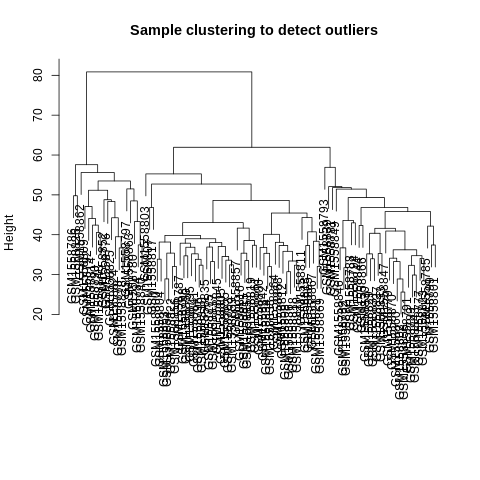

In [ ]:
%%R
datExpr_train <- as.data.frame(t(expr_train))
rownames(datExpr_train) <- colnames(expr_train)

gsg <- goodSamplesGenes(datExpr_train, verbose = 3)
if (!gsg$allOK) datExpr_train <- datExpr_train[gsg$goodSamples, gsg$goodGenes]

# Sample dendrogram
sampleTree <- hclust(dist(datExpr_train), method = "average")
plot(sampleTree, main="Sample clustering to detect outliers", xlab="", sub="")

# Save
png(file.path(OUTDIR,"A_sample_clustering.png"), width=1200, height=600)
plot(sampleTree, main="Sample clustering to detect outliers", xlab="", sub="")
dev.off()

jpeg(file.path(OUTDIR,"A_sample_clustering.jpg"), width=1200, height=600, quality=95)
plot(sampleTree, main="Sample clustering to detect outliers", xlab="", sub="")
dev.off()

pdf(file.path(OUTDIR,"A_sample_clustering.pdf"), width=12, height=6)
plot(sampleTree, main="Sample clustering to detect outliers", xlab="", sub="")
dev.off()


STEP-3: Choose soft power (Fig-C)

pickSoftThreshold: will use block size 2030.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2030 of 22034
   ..working on genes 2031 through 4060 of 22034
   ..working on genes 4061 through 6090 of 22034
   ..working on genes 6091 through 8120 of 22034
   ..working on genes 8121 through 10150 of 22034
   ..working on genes 10151 through 12180 of 22034
   ..working on genes 12181 through 14210 of 22034
   ..working on genes 14211 through 16240 of 22034
   ..working on genes 16241 through 18270 of 22034
   ..working on genes 18271 through 20300 of 22034
   ..working on genes 20301 through 22034 of 22034
   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.02620  4.7400          0.791   11200     11200  11900
2      2  0.27000  3.8400          0.921    6890      6950   8270
3      3  0.04380  0.6070          0.643    4750      4900   6680
4      4  0.00276 -0.0972          0.390    3490      3650   5610
5      5  0

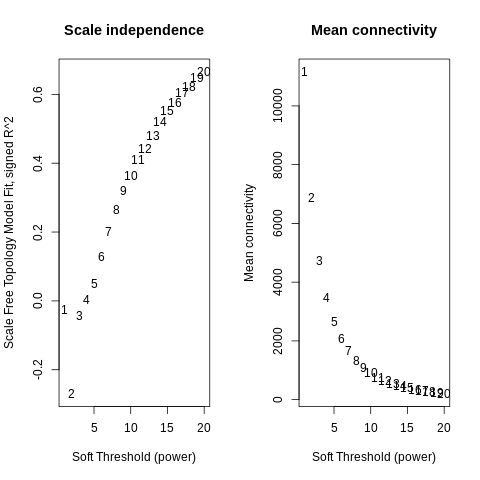

In [ ]:
%%R
powers <- 1:20
sft <- pickSoftThreshold(datExpr_train, powerVector = powers, networkType="signed", verbose=5)

par(mfrow=c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale independence")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2], labels=powers)
abline(h=0.8, col="red")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers)

# Save outputs
png(file.path(OUTDIR,"C_soft_threshold.png"), width=1200, height=600, res=150)
par(mfrow=c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale independence")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2], labels=powers)
abline(h=0.8, col="red")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers)
dev.off()

# Get chosen soft threshold
softPower <- if (!is.na(sft$powerEstimate)) sft$powerEstimate else 6
softPower


pickSoftThreshold: will use block size 2030.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2030 of 22034
   ..working on genes 2031 through 4060 of 22034
   ..working on genes 4061 through 6090 of 22034
   ..working on genes 6091 through 8120 of 22034
   ..working on genes 8121 through 10150 of 22034
   ..working on genes 10151 through 12180 of 22034
   ..working on genes 12181 through 14210 of 22034
   ..working on genes 14211 through 16240 of 22034
   ..working on genes 16241 through 18270 of 22034
   ..working on genes 18271 through 20300 of 22034
   ..working on genes 20301 through 22034 of 22034
   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.02620  4.7400          0.791   11200     11200  11900
2      2  0.27000  3.8400          0.921    6890      6950   8270
3      3  0.04380  0.6070          0.643    4750      4900   6680
4      4  0.00276 -0.0972          0.390    3490      3650   5610
5      5  0

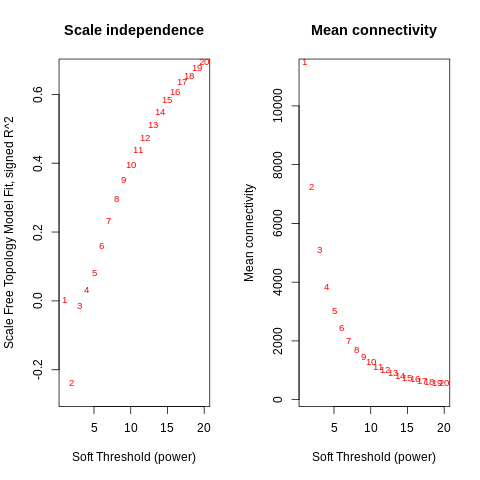

In [ ]:
%%R
powers <- 1:20
sft <- pickSoftThreshold(datExpr_train, powerVector = powers, networkType="signed", verbose=5)

# Plot side by side
par(mfrow=c(1,2))

# Scale independence
plot(sft$fitIndices[,1],
     -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale independence")
text(sft$fitIndices[,1],
     -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     labels=powers, col="red", cex=0.8, pos=3)
abline(h=0.8, col="blue")

# Mean connectivity
plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(sft$fitIndices[,1], sft$fitIndices[,5],
     labels=powers, col="red", cex=0.8, pos=3)

# Save as PNG
png(file.path(OUTDIR,"C_soft_threshold.png"), width=1200, height=600, res=150)
par(mfrow=c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale independence")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     labels=powers, col="red", cex=0.8, pos=3)
abline(h=0.8, col="blue")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(sft$fitIndices[,1], sft$fitIndices[,5],
     labels=powers, col="red", cex=0.8, pos=3)
dev.off()

# Chosen soft threshold
softPower <- if (!is.na(sft$powerEstimate)) sft$powerEstimate else 6
softPower


In [ ]:
%%R
powers <- 1:20
sft <- pickSoftThreshold(datExpr_train, powerVector = powers, networkType="signed", verbose=5)

# PNG save
png(file.path(OUTDIR,"C_soft_threshold.png"), width=1600, height=800, res=150)
par(mfrow=c(1,2))

# ---- Scale independence ----
plot(sft$fitIndices[,1],
     -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     main="Scale independence",
     type="b", pch=19, col="red")   # point + line
abline(h=0.8, col="blue", lty=2)

text(sft$fitIndices[,1],
     -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     labels=powers, col="black", cex=1.2, pos=3)

# ---- Mean connectivity ----
plot(sft$fitIndices[,1],
     sft$fitIndices[,5],
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     main="Mean connectivity",
     type="b", pch=19, col="red")   # point + line

text(sft$fitIndices[,1],
     sft$fitIndices[,5],
     labels=powers, col="black", cex=1.2, pos=3)

dev.off()

# Final chosen soft threshold
softPower <- if (!is.na(sft$powerEstimate)) sft$powerEstimate else 6
softPower


pickSoftThreshold: will use block size 2030.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2030 of 22034
   ..working on genes 2031 through 4060 of 22034
   ..working on genes 4061 through 6090 of 22034
   ..working on genes 6091 through 8120 of 22034
   ..working on genes 8121 through 10150 of 22034
   ..working on genes 10151 through 12180 of 22034
   ..working on genes 12181 through 14210 of 22034
   ..working on genes 14211 through 16240 of 22034
   ..working on genes 16241 through 18270 of 22034
   ..working on genes 18271 through 20300 of 22034
   ..working on genes 20301 through 22034 of 22034
   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.02620  4.7400          0.791   11200     11200  11900
2      2  0.27000  3.8400          0.921    6890      6950   8270
3      3  0.04380  0.6070          0.643    4750      4900   6680
4      4  0.00276 -0.0972          0.390    3490      3650   5610
5      5  0

STEP-4: Network construction + module detection (Fig-B)

 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file WGCNA_outputs/trainTOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction o

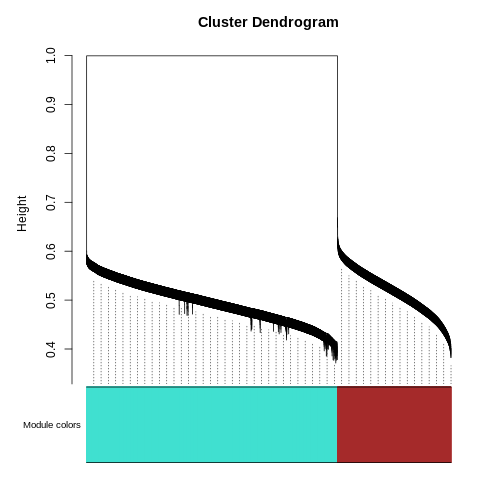

In [ ]:
%%R
net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = file.path(OUTDIR, "trainTOM"),
  verbose = 3
)

moduleColors <- labels2colors(net$colors)

# Dendrogram + colors
plotDendroAndColors(net$dendrograms[[1]],
                    moduleColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Cluster Dendrogram")

# PNG
png(file.path(OUTDIR,"B_cluster_dendrogram.png"), width=1400, height=700, res=150)
plotDendroAndColors(net$dendrograms[[1]],
                    moduleColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Cluster Dendrogram")
dev.off()

# JPEG
jpeg(file.path(OUTDIR,"B_cluster_dendrogram.jpg"), width=1400, height=700, quality=95)
plotDendroAndColors(net$dendrograms[[1]],
                    moduleColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Cluster Dendrogram")
dev.off()

# PDF
pdf(file.path(OUTDIR,"B_cluster_dendrogram.pdf"), width=14, height=7)
plotDendroAndColors(net$dendrograms[[1]],
                    moduleColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Cluster Dendrogram")
dev.off()


 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file WGCNA_outputs/trainTOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction o

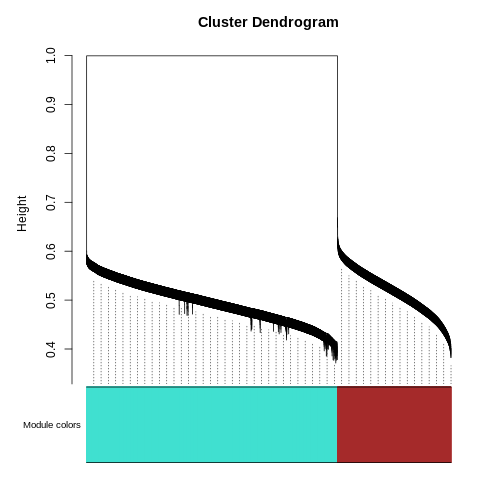

In [ ]:
%%R
# =============================
# WGCNA Cluster Dendrogram Plot
# =============================

net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = file.path(OUTDIR, "trainTOM"),
  verbose = 3
)

# Module colors assign
moduleColors <- labels2colors(net$colors)

# ------------------------
# Plot on screen
# ------------------------
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)

# ------------------------
# Save as PNG
# ------------------------
png(file.path(OUTDIR,"B_cluster_dendrogram.png"), width=1400, height=700, res=150)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()

# ------------------------
# Save as JPEG
# ------------------------
jpeg(file.path(OUTDIR,"B_cluster_dendrogram.jpg"), width=1400, height=700, quality=95)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()

# ------------------------
# Save as PDF
# ------------------------
pdf(file.path(OUTDIR,"B_cluster_dendrogram.pdf"), width=14, height=7)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()


 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file WGCNA_outputs/trainTOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction o

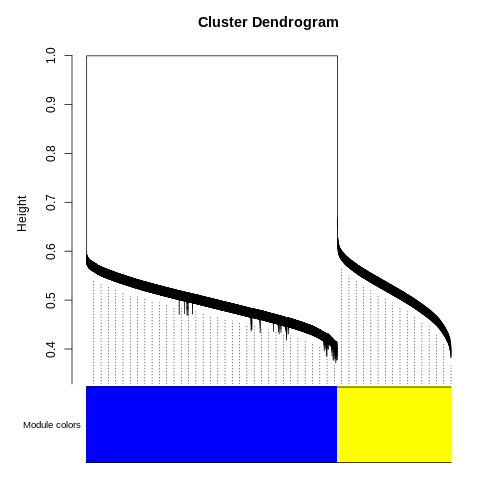

In [ ]:
%%R
# =============================
# WGCNA Cluster Dendrogram Plot
# =============================

net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = file.path(OUTDIR, "trainTOM"),
  verbose = 3
)

# Custom large color palette
manyColors <- c("turquoise","blue","brown","yellow","green","red","black","pink",
                "magenta","purple","greenyellow","tan","salmon","cyan","midnightblue",
                "lightcyan","grey60","lightgreen","lightyellow","royalblue","darkred",
                "darkgreen","darkblue","orange","darkturquoise","skyblue","darkgrey",
                "maroon","lightpink","lavenderblush","palevioletred","seagreen","steelblue",
                "chartreuse","darkorange","aquamarine","violet","gold","plum","orchid",
                "sienna","khaki","tomato","navy","darkmagenta","limegreen","firebrick",
                "coral","dodgerblue","chocolate","mediumseagreen","springgreen")

# Map module labels to many colors
moduleColors <- manyColors[as.numeric(factor(net$colors))]

# ------------------------
# Plot on screen
# ------------------------
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)


 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file WGCNA_outputs/trainTOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction o

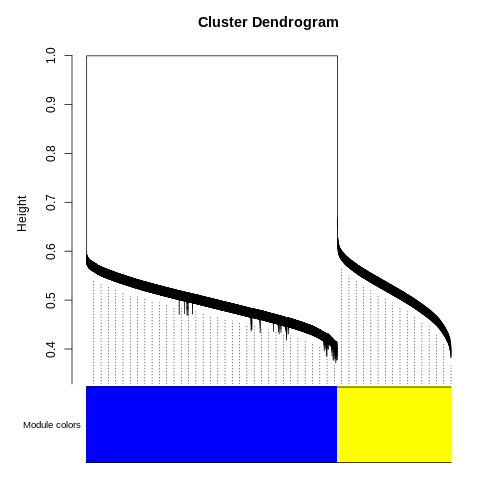

In [ ]:
%%R
# =============================
# WGCNA Cluster Dendrogram Plot
# =============================

net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = file.path(OUTDIR, "trainTOM"),
  verbose = 3
)

# Custom large color palette (৫০+ রঙ)
manyColors <- c("turquoise","blue","brown","yellow","green","red","black","pink",
                "magenta","purple","greenyellow","tan","salmon","cyan","midnightblue",
                "lightcyan","grey60","lightgreen","lightyellow","royalblue","darkred",
                "darkgreen","darkblue","orange","darkturquoise","skyblue","darkgrey",
                "maroon","lightpink","lavenderblush","palevioletred","seagreen","steelblue",
                "chartreuse","darkorange","aquamarine","violet","gold","plum","orchid",
                "sienna","khaki","tomato","navy","darkmagenta","limegreen","firebrick",
                "coral","dodgerblue","chocolate","mediumseagreen","springgreen")

# Map module labels to many colors
moduleColors <- manyColors[as.numeric(factor(net$colors))]

# ------------------------
# Plot on screen
# ------------------------
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)

# ------------------------
# Save as PNG
# ------------------------
png(file.path(OUTDIR,"B_cluster_dendrogram.png"), width=1400, height=700, res=150)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()

# ------------------------
# Save as JPEG
# ------------------------
jpeg(file.path(OUTDIR,"B_cluster_dendrogram.jpg"), width=1400, height=700, quality=95)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()

# ------------------------
# Save as PDF
# ------------------------
pdf(file.path(OUTDIR,"B_cluster_dendrogram.pdf"), width=14, height=7)
plotDendroAndColors(
  net$dendrograms[[1]],
  moduleColors[net$blockGenes[[1]]],
  "Module colors",
  dendroLabels = FALSE,
  hang = 0.03,
  addGuide = TRUE,
  guideHang = 0.05,
  main = "Cluster Dendrogram"
)
dev.off()


STEP-6: Best module genes + GS vs MM scatter

[1] "Best module: "
Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  No genes found in the best module. Cannot proceed to GS vs MM plotting.


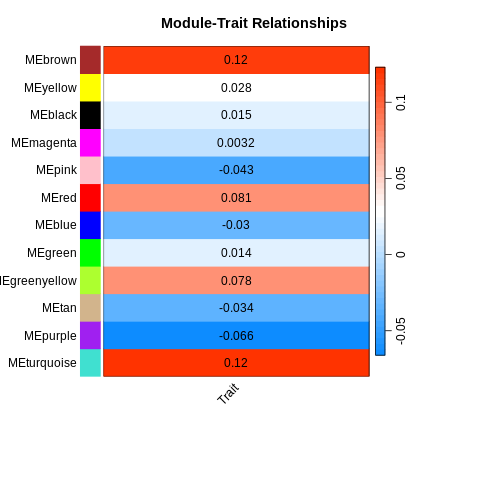

RInterpreterError: Failed to parse and evaluate line '# ================================================\n#   WGCNA: Best Module Identification + GS vs MM\n# ================================================\n\n# --------------------------------\n# 0. Trait data load/define\n# --------------------------------\n# যদি আপনার external trait.csv থাকে:\n# trait <- read.csv("trait.csv", row.names = 1)\n\n# উদাহরণস্বরূপ, case/control binary trait (0/1)\ntrait <- data.frame(Trait = c(rep(0, nrow(datExpr_train)/2),\n                              rep(1, nrow(datExpr_train)/2)))\nrownames(trait) <- rownames(datExpr_train)\n\n# --------------------------------\n# 1. Module eigengenes বের করা\n# --------------------------------\nMEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes\nMEs  <- orderMEs(MEs0)   # eigengenes reorder\n\n# --------------------------------\n# 2. Module–Trait correlation\n# --------------------------------\nmoduleTraitCor    <- cor(MEs, trait, use = "p")\n

In [ ]:
%%R
# ================================================
#   WGCNA: Best Module Identification + GS vs MM
# ================================================

# --------------------------------
# 0. Trait data load/define
# --------------------------------
# যদি আপনার external trait.csv থাকে:
# trait <- read.csv("trait.csv", row.names = 1)

# উদাহরণস্বরূপ, case/control binary trait (0/1)
trait <- data.frame(Trait = c(rep(0, nrow(datExpr_train)/2),
                              rep(1, nrow(datExpr_train)/2)))
rownames(trait) <- rownames(datExpr_train)

# --------------------------------
# 1. Module eigengenes বের করা
# --------------------------------
MEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes
MEs  <- orderMEs(MEs0)   # eigengenes reorder

# --------------------------------
# 2. Module–Trait correlation
# --------------------------------
moduleTraitCor    <- cor(MEs, trait, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr_train))

# Heatmap (optional)
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = names(trait),
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = signif(moduleTraitCor, 2),
               main = "Module-Trait Relationships")

# --------------------------------
# 3. Best module নির্বাচন
# --------------------------------
if (all(is.na(moduleTraitCor))) {
  stop("All module-trait correlations are NA. Cannot select best module.")
}

bestModule <- names(which.max(abs(moduleTraitCor)))
print(paste("Best module:", bestModule))

moduleColorOfBest <- gsub("ME","",bestModule)

# --------------------------------
# 4. Best module gene list বের করা
# --------------------------------
inBestModule    <- moduleColors == moduleColorOfBest
bestModuleGenes <- colnames(datExpr_train)[inBestModule]

if (length(bestModuleGenes) == 0) {
  stop("No genes found in the best module. Cannot proceed to GS vs MM plotting.")
}

write.csv(bestModuleGenes,
          file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")),
          row.names = FALSE)

# --------------------------------
# 5. Module Membership (MM) এবং Gene Significance (GS)
# --------------------------------
MM <- as.data.frame(cor(datExpr_train, MEs, use="p"))
GS <- as.data.frame(cor(datExpr_train, trait$Trait, use="p"))
colnames(GS) <- "GS.Trait"
names(MM) <- paste0("kME_", names(MM))

MM_best <- as.numeric(MM[[paste0("kME_", bestModule)]])   # numeric এ কনভার্ট
GS_trait <- as.numeric(GS$GS.Trait)                       # numeric এ কনভার্ট

# --------------------------------
# 6. GS vs MM Plot (Screen + Save)
# --------------------------------
# Only finite values
idx <- which(is.finite(MM_best[inBestModule]) & is.finite(GS_trait[inBestModule]))

if (length(idx) == 0) {
  stop("No finite MM or GS values to plot for the best module.")
}

colors_all <- rainbow(length(idx))  # plot colors

# Function to plot
plot_GS_vs_MM <- function(filename) {
  png(file.path(OUTDIR, filename), width=1200, height=900)
  plot(abs(MM_best[inBestModule][idx]),
       abs(GS_trait[inBestModule][idx]),
       col = colors_all,
       pch = 19,
       xlab = paste("Module Membership in", bestModule),
       ylab = "Gene Significance for Trait",
       main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
  dev.off()
}

# Screen plot
plot(abs(MM_best[inBestModule][idx]),
     abs(GS_trait[inBestModule][idx]),
     col = colors_all,
     pch = 19,
     xlab = paste("Module Membership in", bestModule),
     ylab = "Gene Significance for Trait",
     main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))

# Save PNG
plot_GS_vs_MM(paste0("GS_vs_MM_", moduleColorOfBest, ".png"))
# Save JPEG
jpeg(file.path(OUTDIR, paste0("GS_vs_MM_", moduleColorOfBest, ".jpeg")), width=1200, height=900)
plot(abs(MM_best[inBestModule][idx]),
     abs(GS_trait[inBestModule][idx]),
     col = colors_all,
     pch = 19,
     xlab = paste("Module Membership in", bestModule),
     ylab = "Gene Significance for Trait",
     main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
dev.off()
# Save PDF
pdf(file.path(OUTDIR, paste0("GS_vs_MM_", moduleColorOfBest, ".pdf")), width=12, height=9)
plot(abs(MM_best[inBestModule][idx]),
     abs(GS_trait[inBestModule][idx]),
     col = colors_all,
     pch = 19,
     xlab = paste("Module Membership in", bestModule),
     ylab = "Gene Significance for Trait",
     main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
dev.off()


Best module: 


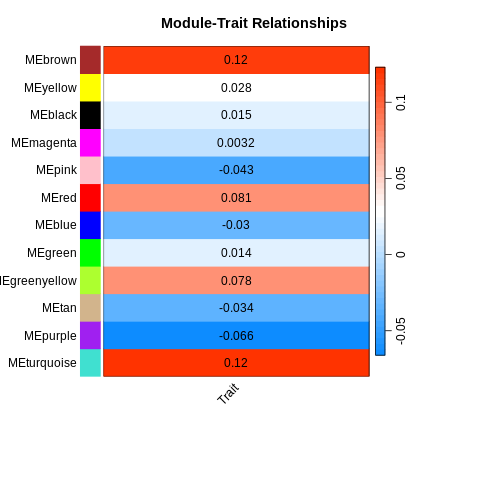

In [ ]:
%%R
# ================================================
#   WGCNA: Best Module Identification + GS vs MM
# ================================================

# --------------------------------
# 0. Trait data load/define
# --------------------------------
# যদি আপনার external trait.csv থাকে:
# trait <- read.csv("trait.csv", row.names = 1)

# উদাহরণস্বরূপ, case/control binary trait (0/1)
trait <- data.frame(Trait = c(rep(0, nrow(datExpr_train)/2),
                              rep(1, nrow(datExpr_train)/2)))
rownames(trait) <- rownames(datExpr_train)

# --------------------------------
# 1. Module eigengenes বের করা
# --------------------------------
MEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes
MEs  <- orderMEs(MEs0)   # eigengenes reorder

# --------------------------------
# 2. Module–Trait correlation
# --------------------------------
moduleTraitCor    <- cor(MEs, trait, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr_train))

# Heatmap (optional)
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = names(trait),
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = signif(moduleTraitCor, 2),
               main = "Module-Trait Relationships")

# --------------------------------
# 3. Best module নির্বাচন
# --------------------------------
if (all(is.na(moduleTraitCor))) {
  stop("All module-trait correlations are NA. Cannot select best module.")
}

bestModule <- names(which.max(abs(moduleTraitCor)))
moduleColorOfBest <- gsub("ME","",bestModule)
cat("Best module:", bestModule, "\n")

# --------------------------------
# 4. Best module gene list বের করা
# --------------------------------
inBestModule    <- moduleColors == moduleColorOfBest
bestModuleGenes <- colnames(datExpr_train)[inBestModule]

if (length(bestModuleGenes) == 0) {
  warning("No genes found in the best module. Skipping GS vs MM plotting.")
} else {
  write.csv(bestModuleGenes,
            file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")),
            row.names = FALSE)

  # --------------------------------
  # 5. Module Membership (MM) এবং Gene Significance (GS)
  # --------------------------------
  MM <- as.data.frame(cor(datExpr_train, MEs, use="p"))
  GS <- as.data.frame(cor(datExpr_train, trait$Trait, use="p"))
  colnames(GS) <- "GS.Trait"
  names(MM) <- paste0("kME_", names(MM))

  MM_best <- as.numeric(MM[[paste0("kME_", bestModule)]])
  GS_trait <- as.numeric(GS$GS.Trait)

  # --------------------------------
  # 6. GS vs MM Plot (Screen + Save)
  # --------------------------------
  idx <- which(is.finite(MM_best[inBestModule]) & is.finite(GS_trait[inBestModule]))

  if (length(idx) == 0) {
    warning("No finite MM or GS values to plot for the best module. Skipping plotting.")
  } else {
    colors_all <- rainbow(length(idx))

    # Screen plot
    plot(abs(MM_best[inBestModule][idx]),
         abs(GS_trait[inBestModule][idx]),
         col = colors_all,
         pch = 19,
         xlab = paste("Module Membership in", bestModule),
         ylab = "Gene Significance for Trait",
         main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))

    # Save PNG
    png(file.path(OUTDIR, paste0("GS_vs_MM_", moduleColorOfBest, ".png")), width=1200, height=900)
    plot(abs(MM_best[inBestModule][idx]),
         abs(GS_trait[inBestModule][idx]),
         col = colors_all,
         pch = 19,
         xlab = paste("Module Membership in", bestModule),
         ylab = "Gene Significance for Trait",
         main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
    dev.off()

    # Save JPEG
    jpeg(file.path(OUTDIR, paste0("GS_vs_MM_", moduleColorOfBest, ".jpeg")), width=1200, height=900)
    plot(abs(MM_best[inBestModule][idx]),
         abs(GS_trait[inBestModule][idx]),
         col = colors_all,
         pch = 19,
         xlab = paste("Module Membership in", bestModule),
         ylab = "Gene Significance for Trait",
         main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
    dev.off()

    # Save PDF
    pdf(file.path(OUTDIR, paste0("GS_vs_MM_", moduleColorOfBest, ".pdf")), width=12, height=9)
    plot(abs(MM_best[inBestModule][idx]),
         abs(GS_trait[inBestModule][idx]),
         col = colors_all,
         pch = 19,
         xlab = paste("Module Membership in", bestModule),
         ylab = "Gene Significance for Trait",
         main = paste("Module Membership vs. Gene Significance\nBest Module:", bestModule))
    dev.off()
  }
}


In [ ]:
%%R
# Install BiocManager if not available
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Install WGCNA
if (!requireNamespace("WGCNA", quietly = TRUE)) {
  BiocManager::install("WGCNA")
}

# Load library
library(WGCNA)

options(stringsAsFactors = FALSE)
allowWGCNAThreads()


Allowing multi-threading with up to 2 threads.


In [ ]:
%%R
# Step 1: Pick Soft Threshold
powers = c(1:20)
sft = pickSoftThreshold(datExpr_train, powerVector = powers, verbose = 5)
softPower = ifelse(is.na(sft$powerEstimate), 6, sft$powerEstimate)

# Step 2: Network Construction
adjacency = adjacency(datExpr_train, power = softPower)
TOM = TOMsimilarity(adjacency)
dissTOM = 1 - TOM
geneTree = hclust(as.dist(dissTOM), method = "average")

# Step 3: Module Detection
dynamicMods = cutreeDynamic(dendro = geneTree, distM = dissTOM,
                            deepSplit = 2, pamRespectsDendro = FALSE,
                            minClusterSize = 30)
moduleColors = labels2colors(dynamicMods)

# Step 4: Eigengenes
MEs0 = moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes
MEs  = orderMEs(MEs0)

# Step 5: Module-Trait Correlation
moduleTraitCor    <- cor(MEs, trait, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr_train))

# Heatmap
pdf("Module_Trait_Relationships.pdf", width=10, height=8)
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = names(trait),
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = paste(signif(moduleTraitCor,2), "\n(",
                                  signif(moduleTraitPvalue,1), ")", sep = ""),
               setStdMargins = FALSE,
               cex.text = 0.6,
               zlim = c(-1,1),
               main = "Module–Trait Relationships")
dev.off()


pickSoftThreshold: will use block size 800.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 800 of 800
   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1    0.149  0.349          0.351 232.000  244.0000 377.00
2      2    0.275 -0.438          0.562  97.000   96.8000 218.00
3      3    0.531 -0.791          0.751  48.000   44.9000 138.00
4      4    0.623 -0.994          0.834  26.400   22.2000  91.50
5      5    0.710 -1.100          0.889  15.600   11.4000  63.00
6      6    0.742 -1.140          0.907   9.720    6.1700  44.50
7      7    0.777 -1.140          0.920   6.340    3.4600  32.10
8      8    0.759 -1.170          0.868   4.290    2.1100  23.50
9      9    0.867 -1.130          0.940   3.010    1.3000  18.20
10    10    0.781 -1.280          0.882   2.170    0.7920  15.20
11    11    0.848 -1.290          0.905   1.600    0.5090  12.90
12    12    0.882 -1.310          0.932   1.220    0.3110  10.90
13 

In [ ]:
from google.colab import files
files.download("Module_Trait_Relationships.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%R
library(WGCNA)
options(stringsAsFactors = FALSE)
allowWGCNAThreads()

# ---------------------------
# 1. Detect modules
# ---------------------------
net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = FALSE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = "TOM",
  verbose = 3
)

moduleColors <- net$colors
nSamples <- nrow(datExpr_train)

# ---------------------------
# 2. Module Eigengenes
# ---------------------------
MEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes
MEs  <- orderMEs(MEs0)

# ---------------------------
# 3. Correlate modules with trait
# ---------------------------
# Ensure trait is available
if (!exists("trait")) stop("Trait object not found!")

moduleTraitCor <- cor(MEs, trait, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples)

# ---------------------------
# 4. Best module
# ---------------------------
bestModule <- names(which.max(abs(moduleTraitCor)))
cat("Best module is:", bestModule, "\n")
moduleColorOfBest <- gsub("ME", "", bestModule)

# ---------------------------
# 5. Genes in best module
# ---------------------------
inBestModule <- moduleColors == moduleColorOfBest
bestModuleGenes <- colnames(datExpr_train)[inBestModule]

write.csv(bestModuleGenes,
          file = file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")),
          row.names = FALSE)

# ---------------------------
# 6. Module Membership (MM) and Gene Significance (GS)
# ---------------------------
MM <- as.data.frame(cor(datExpr_train, MEs, use = "p"))
names(MM) <- paste0("kME_", names(MM))

# Use first trait column for GS
GS <- as.data.frame(cor(datExpr_train, trait[[1]], use = "p"))
colnames(GS) <- "GS.Trait"

MM_best <- MM[[paste0("kME_", bestModule)]]

# ---------------------------
# 7. Plot GS vs MM
# ---------------------------
plot(abs(MM_best[inBestModule]), abs(GS$GS.Trait[inBestModule]),
     xlab = paste("Module Membership in", moduleColorOfBest),
     ylab = "Gene Significance for Trait",
     main = "GS vs MM (best module)")
abline(lm(abs(GS$GS.Trait[inBestModule]) ~ abs(MM_best[inBestModule])), lty = 2)

# Save figures
png(file.path(OUTDIR,"GS_vs_MM_bestModule.png"), width = 800, height = 600, res = 150)
plot(abs(MM_best[inBestModule]), abs(GS$GS.Trait[inBestModule]),
     xlab = paste("Module Membership in", moduleColorOfBest),
     ylab = "Gene Significance for Trait",
     main = "GS vs MM (best module)")
abline(lm(abs(GS$GS.Trait[inBestModule]) ~ abs(MM_best[inBestModule])), lty = 2)
dev.off()

jpeg(file.path(OUTDIR,"GS_vs_MM_bestModule.jpg"), width = 800, height = 600, quality = 95)
plot(abs(MM_best[inBestModule]), abs(GS$GS.Trait[inBestModule]),
     xlab = paste("Module Membership in", moduleColorOfBest),
     ylab = "Gene Significance for Trait",
     main = "GS vs MM (best module)")
abline(lm(abs(GS$GS.Trait[inBestModule]) ~ abs(MM_best[inBestModule])), lty = 2)
dev.off()

pdf(file.path(OUTDIR,"GS_vs_MM_bestModule.pdf"), width = 8, height = 6)
plot(abs(MM_best[inBestModule]), abs(GS$GS.Trait[inBestModule]),
     xlab = paste("Module Membership in", moduleColorOfBest),
     ylab = "Gene Significance for Trait",
     main = "GS vs MM (best module)")
abline(lm(abs(GS$GS.Trait[inBestModule]) ~ abs(MM_best[inBestModule])), lty = 2)
dev.off()


Allowing multi-threading with up to 2 threads.
 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file TOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 2 .
    TOM calculation: adjacency..
    ..will use 2 paral

RInterpreterError: Failed to parse and evaluate line 'library(WGCNA)\noptions(stringsAsFactors = FALSE)\nallowWGCNAThreads()\n\n# ---------------------------\n# 1. Detect modules\n# ---------------------------\nnet <- blockwiseModules(\n  datExpr_train,\n  power = softPower,\n  TOMType = "signed",\n  networkType = "signed",\n  minModuleSize = 30,\n  reassignThreshold = 0,\n  mergeCutHeight = 0.25,\n  numericLabels = FALSE,\n  pamRespectsDendro = FALSE,\n  saveTOMs = TRUE,\n  saveTOMFileBase = "TOM",\n  verbose = 3\n)\n\nmoduleColors <- net$colors\nnSamples <- nrow(datExpr_train)\n\n# ---------------------------\n# 2. Module Eigengenes\n# ---------------------------\nMEs0 <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes\nMEs  <- orderMEs(MEs0)\n\n# ---------------------------\n# 3. Correlate modules with trait\n# ---------------------------\n# Ensure trait is available\nif (!exists("trait")) stop("Trait object not found!")\n\nmoduleTraitCor <- cor(MEs, trait, use = "

In [ ]:
!pip install rpy2


In [ ]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# ==============================
# WGCNA Hub Gene Analysis
# Complete start-to-finish script
# ==============================
%%R
library(WGCNA)
options(stringsAsFactors = FALSE)

# -----------------------------
# 1. Load expression and trait data
# -----------------------------
# Replace these paths with your actual CSV files
datExpr_train <- read.csv("expression_train.csv", row.names=1, check.names=FALSE)
trait <- read.csv("trait.csv", row.names=1, check.names=FALSE)

# Make sure samples are in rows
datExpr_train <- as.data.frame(t(datExpr_train))
trait <- as.data.frame(trait)

# -----------------------------
# 2. Choose soft-threshold power
# -----------------------------
softPower <- 6  # Replace with the power you selected from scale-free analysis

# -----------------------------
# 3. Detect WGCNA modules
# -----------------------------
net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = FALSE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = "TOM",
  verbose = 3
)

moduleColors <- net$colors
MEs <- orderMEs(moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes)

# -----------------------------
# 4. Define candidate hub genes
# -----------------------------
common_list <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                 "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                 "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")
degree_hubs <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
candidates <- unique(c(common_list, degree_hubs))

# Output folder
OUTDIR <- "WGCNA_outputs"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR)

# -----------------------------
# 5. Check candidate genes in training data
# -----------------------------
genes_present <- intersect(candidates, colnames(datExpr_train))
genes_missing <- setdiff(candidates, colnames(datExpr_train))
cat("Present in training:", length(genes_present), "\nMissing:", length(genes_missing), "\n")
if(length(genes_missing) > 0) {
  write.csv(data.frame(missing=genes_missing),
            file.path(OUTDIR,"missing_in_training.csv"),
            row.names=FALSE)
}

# -----------------------------
# 6. Module membership (kME)
# -----------------------------
MM_all <- as.data.frame(cor(datExpr_train, MEs, use="p"))
colnames(MM_all) <- paste0("kME_", colnames(MEs))

# -----------------------------
# 7. Intramodular connectivity
# -----------------------------
adj <- adjacency(datExpr_train, power=softPower)
imc <- intramodularConnectivity(adj, moduleColors)
imc <- imc[, c("kWithin","kOut","kTotal")]

# -----------------------------
# 8. Prepare per-trait summaries
# -----------------------------
all_trait_summaries <- list()

for(traitName in colnames(trait)) {

  # Best module for this trait
  moduleTraitCor <- cor(MEs, trait[[traitName]], use="p")
  bestModule <- names(which.max(abs(moduleTraitCor)))
  bestColor <- sub("^ME","", bestModule)
  inBest <- moduleColors == bestColor

  # Gene significance (GS)
  GS <- as.numeric(cor(datExpr_train, trait[[traitName]], use="p"))
  names(GS) <- colnames(datExpr_train)

  # Build summary dataframe
  df <- data.frame(
    Gene = genes_present,
    Module = moduleColors[match(genes_present, colnames(datExpr_train))],
    kME_best = abs(MM_all[genes_present, bestModule]),
    GS = abs(GS[genes_present]),
    kWithin = imc$kWithin[match(genes_present, rownames(imc))],
    stringsAsFactors = FALSE
  )
  df$InBestModule <- df$Module == bestColor
  df$Trait <- traitName

  # Rank genes: inside best module by kME, outside by GS
  df <- df[order(df$InBestModule, df$kME_best, df$GS, decreasing=TRUE), ]
  all_trait_summaries[[traitName]] <- df

  # Save per-trait table
  write.csv(df, file.path(OUTDIR, paste0("hub_validation_", traitName, ".csv")), row.names=FALSE)
}

# -----------------------------
# 9. Combined table
# -----------------------------
combined <- do.call(rbind, all_trait_summaries)
write.csv(combined, file.path(OUTDIR, "hub_validation_all_traits.csv"), row.names=FALSE)

# -----------------------------
# 10. Barplot for top candidates
# -----------------------------
topTrait <- names(which.max(colSums(abs(cor(MEs, trait, use="p")))))
df_top <- all_trait_summaries[[topTrait]]
top_show <- head(df_top[df_top$InBestModule, ], 10)

png(file.path(OUTDIR, paste0("Top10_kME_in_best_module_", topTrait, ".png")),
    width=1200, height=800, res=150)
par(mar=c(10,5,3,2))
barplot(top_show$kME_best, names.arg = top_show$Gene, las=2,
        main=paste("Top |kME| in best module (Trait:", topTrait, ")"),
        ylab="|kME|")
dev.off()

cat("All hub gene analysis finished! Check folder:", OUTDIR, "\n")


Error in file(file, "rt") : cannot open the connection
In addition: Warning message:
In file(file, "rt") :
  cannot open file 'expression_train.csv': No such file or directory
Error in file(file, "rt") : cannot open the connection


RInterpreterError: Failed to parse and evaluate line 'library(WGCNA)\noptions(stringsAsFactors = FALSE)\n\n# -----------------------------\n# 1. Load expression and trait data\n# -----------------------------\n# Replace these paths with your actual CSV files\ndatExpr_train <- read.csv("expression_train.csv", row.names=1, check.names=FALSE)\ntrait <- read.csv("trait.csv", row.names=1, check.names=FALSE)\n\n# Make sure samples are in rows\ndatExpr_train <- as.data.frame(t(datExpr_train))\ntrait <- as.data.frame(trait)\n\n# -----------------------------\n# 2. Choose soft-threshold power\n# -----------------------------\nsoftPower <- 6  # Replace with the power you selected from scale-free analysis\n\n# -----------------------------\n# 3. Detect WGCNA modules\n# -----------------------------\nnet <- blockwiseModules(\n  datExpr_train,\n  power = softPower,\n  TOMType = "signed",\n  networkType = "signed",\n  minModuleSize = 30,\n  reassignThreshold = 0,\n  mergeCutHeight = 0.25,\n  numeric

In [ ]:
%%R
# R কোড এখানে লিখবেন
expr_train <- read.csv("/content/GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
                       row.names=1, check.names=FALSE)

head(expr_train)

datExpr_train <- as.data.frame(t(expr_train))
write.csv(datExpr_train, "expression_train.csv", row.names=TRUE)


In [ ]:
%%R
labels <- read.csv("/content/GSE63878_labels.csv", row.names=1, check.names=FALSE)

# Check first few rows
head(labels)

# Make sure sample order matches expression matrix
labels <- labels[rownames(datExpr_train), , drop=FALSE]

# Save as CSV for WGCNA
write.csv(labels, "trait.csv", row.names=TRUE)


In [ ]:
# ==============================
# WGCNA Hub Gene Analysis
# Complete start-to-finish script
# ==============================
%%R
library(WGCNA)
options(stringsAsFactors = FALSE)

# -----------------------------
# 1. Load expression and trait data
# -----------------------------
# Replace these paths with your actual CSV files
datExpr_train <- read.csv("/content/GSE63878_expression.csv", row.names=1, check.names=FALSE)
trait <- read.csv("/content/GSE63878_labels.csv", row.names=1, check.names=FALSE)

# Make sure samples are in rows
datExpr_train <- as.data.frame(t(datExpr_train))
trait <- as.data.frame(trait)

# -----------------------------
# 2. Choose soft-threshold power
# -----------------------------
softPower <- 6  # Replace with the power you selected from scale-free analysis

# -----------------------------
# 3. Detect WGCNA modules
# -----------------------------
net <- blockwiseModules(
  datExpr_train,
  power = softPower,
  TOMType = "signed",
  networkType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = FALSE,
  pamRespectsDendro = FALSE,
  saveTOMs = TRUE,
  saveTOMFileBase = "TOM",
  verbose = 3
)

moduleColors <- net$colors
MEs <- orderMEs(moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes)

# -----------------------------
# 4. Define candidate hub genes
# -----------------------------
common_list <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                 "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                 "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")
degree_hubs <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
candidates <- unique(c(common_list, degree_hubs))

# Output folder
OUTDIR <- "WGCNA_outputs"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR)

# -----------------------------
# 5. Check candidate genes in training data
# -----------------------------
genes_present <- intersect(candidates, colnames(datExpr_train))
genes_missing <- setdiff(candidates, colnames(datExpr_train))
cat("Present in training:", length(genes_present), "\nMissing:", length(genes_missing), "\n")
if(length(genes_missing) > 0) {
  write.csv(data.frame(missing=genes_missing),
            file.path(OUTDIR,"missing_in_training.csv"),
            row.names=FALSE)
}

# -----------------------------
# 6. Module membership (kME)
# -----------------------------
MM_all <- as.data.frame(cor(datExpr_train, MEs, use="p"))
colnames(MM_all) <- paste0("kME_", colnames(MEs))

# -----------------------------
# 7. Intramodular connectivity
# -----------------------------
adj <- adjacency(datExpr_train, power=softPower)
imc <- intramodularConnectivity(adj, moduleColors)
imc <- imc[, c("kWithin","kOut","kTotal")]

# -----------------------------
# 8. Prepare per-trait summaries
# -----------------------------
all_trait_summaries <- list()

for(traitName in colnames(trait)) {

  # Best module for this trait
  moduleTraitCor <- cor(MEs, trait[[traitName]], use="p")
  bestModule <- names(which.max(abs(moduleTraitCor)))
  bestColor <- sub("^ME","", bestModule)
  inBest <- moduleColors == bestColor

  # Gene significance (GS)
  GS <- as.numeric(cor(datExpr_train, trait[[traitName]], use="p"))
  names(GS) <- colnames(datExpr_train)

  # Build summary dataframe
  df <- data.frame(
    Gene = genes_present,
    Module = moduleColors[match(genes_present, colnames(datExpr_train))],
    kME_best = abs(MM_all[genes_present, bestModule]),
    GS = abs(GS[genes_present]),
    kWithin = imc$kWithin[match(genes_present, rownames(imc))],
    stringsAsFactors = FALSE
  )
  df$InBestModule <- df$Module == bestColor
  df$Trait <- traitName

  # Rank genes: inside best module by kME, outside by GS
  df <- df[order(df$InBestModule, df$kME_best, df$GS, decreasing=TRUE), ]
  all_trait_summaries[[traitName]] <- df

  # Save per-trait table
  write.csv(df, file.path(OUTDIR, paste0("hub_validation_", traitName, ".csv")), row.names=FALSE)
}

# -----------------------------
# 9. Combined table
# -----------------------------
combined <- do.call(rbind, all_trait_summaries)
write.csv(combined, file.path(OUTDIR, "hub_validation_all_traits.csv"), row.names=FALSE)

# -----------------------------
# 10. Barplot for top candidates
# -----------------------------
topTrait <- names(which.max(colSums(abs(cor(MEs, trait, use="p")))))
df_top <- all_trait_summaries[[topTrait]]
top_show <- head(df_top[df_top$InBestModule, ], 10)

png(file.path(OUTDIR, paste0("Top10_kME_in_best_module_", topTrait, ".png")),
    width=1200, height=800, res=150)
par(mar=c(10,5,3,2))
barplot(top_show$kME_best, names.arg = top_show$Gene, las=2,
        main=paste("Top |kME| in best module (Trait:", topTrait, ")"),
        ylab="|kME|")
dev.off()

cat("All hub gene analysis finished! Check folder:", OUTDIR, "\n")


 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
  ..Excluding 1 genes from the calculation due to too many missing samples or zero variance.
    ..step 2
 ....pre-clustering genes to determine blocks..
   Projective K-means:
   ..k-means clustering..
   ..merging smaller clusters...
Block sizes:
gBlocks
   1    2    3    4    5 
5000 4999 4995 4296 2744 
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will use 2 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
   ..saving TOM for block 1 into file TOM-block.1.RData
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 1 genes from module 1 because their KME is too low.
     ..removing 3 genes from module 2 because their KME is too low.
 ..Working on block 

In [ ]:
%%R
DE_threshold_logFC <- 0.585  # ~1.5x
DE_threshold_FDR   <- 0.05

# Run limma function
run_limma <- function(expr, group01){
  design <- model.matrix(~ group01)
  fit <- lmFit(expr, design)
  fit <- eBayes(fit)
  tt <- topTable(fit, coef=2, number=Inf, sort.by="P")
  tt$gene <- rownames(tt)
  tt
}

# Apply to train and test
limma_train <- run_limma(expr_train[, rownames(datExpr_train)], lab_train$Group)
limma_test  <- run_limma(expr_test[,  lab_test$Sample],         lab_test$Group)

# Differentially expressed genes
DEG_train <- subset(limma_train, adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene
DEG_test  <- subset(limma_test,  adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene

# Venn diagram sets
venn_sets <- list(
  Train_DEGs = DEG_train,
  Test_DEGs  = DEG_test,
  WGCNA_BestModule = bestModuleGenes,
  Top10_Degree = Top10_list
)

# Draw venn
grid.newpage()
v <- venn.diagram(
  venn_sets, filename=NULL, cex=1.2, cat.cex=1.2,
  fill=c("#9ecae1","#a1d99b","#fdae6b","#bcbddc"), alpha=0.6,
  main="Intersecting genes: Train/Test DEGs, WGCNA module, Top10"
)
grid.draw(v)

# Save venn diagram
png(file.path(OUTDIR,"E_venn_DEG_WGCNA_Top10.png"), width=1200, height=900, res=150)
grid.draw(v); dev.off()

jpeg(file.path(OUTDIR,"E_venn_DEG_WGCNA_Top10.jpg"), width=1200, height=900, quality=95)
grid.draw(v); dev.off()

pdf(file.path(OUTDIR,"E_venn_DEG_WGCNA_Top10.pdf"), width=12, height=9)
grid.draw(v); dev.off()

# Save intersections as CSV
write.csv(intersect(DEG_train, DEG_test), file.path(OUTDIR,"intersect_Train_Test.csv"), row.names=FALSE)
write.csv(intersect(DEG_train, bestModuleGenes), file.path(OUTDIR,"intersect_Train_WGCNA.csv"), row.names=FALSE)
write.csv(intersect(DEG_test,  bestModuleGenes), file.path(OUTDIR,"intersect_Test_WGCNA.csv"), row.names=FALSE)
write.csv(Reduce(intersect, list(DEG_train, DEG_test, bestModuleGenes, Top10_list)),
          file.path(OUTDIR,"intersect_All_Four.csv"), row.names=FALSE)


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'bestModuleGenes' not found


RInterpreterError: Failed to parse and evaluate line 'DE_threshold_logFC <- 0.585  # ~1.5x\nDE_threshold_FDR   <- 0.05\n\n# Run limma function\nrun_limma <- function(expr, group01){\n  design <- model.matrix(~ group01)\n  fit <- lmFit(expr, design)\n  fit <- eBayes(fit)\n  tt <- topTable(fit, coef=2, number=Inf, sort.by="P")\n  tt$gene <- rownames(tt)\n  tt\n}\n\n# Apply to train and test\nlimma_train <- run_limma(expr_train[, rownames(datExpr_train)], lab_train$Group)\nlimma_test  <- run_limma(expr_test[,  lab_test$Sample],         lab_test$Group)\n\n# Differentially expressed genes\nDEG_train <- subset(limma_train, adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene\nDEG_test  <- subset(limma_test,  adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene\n\n# Venn diagram sets\nvenn_sets <- list(\n  Train_DEGs = DEG_train,\n  Test_DEGs  = DEG_test,\n  WGCNA_BestModule = bestModuleGenes,\n  Top10_Degree = Top10_list\n)\n\n# Draw venn\ngrid.newpage()\nv 

In [ ]:
%%R
# ==========================
# Step 1: WGCNA থেকে best module নির্বাচন
# ==========================

# moduleTraitCor থেকে সবচেয়ে significant module নির্বাচন
bestModule <- names(which.max(abs(moduleTraitCor)))
cat("Best Module: ", bestModule, "\n")

# module name থেকে "ME" prefix সরানো
moduleColorOfBest <- gsub("ME", "", bestModule)

# কোন genes এই best module এ আছে
inBestModule <- moduleColors == moduleColorOfBest
bestModuleGenes <- colnames(datExpr_train)[inBestModule]

# এই genes কে CSV এ সংরক্ষণ
write.csv(bestModuleGenes,
          file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")),
          row.names = FALSE)

# ==========================
# Step 2: limma দিয়ে DEGs বের করা
# ==========================
library(limma)

# Threshold সেট করা
DE_threshold_logFC <- 0.585  # ~1.5 fold change
DE_threshold_FDR   <- 0.05

# limma function
run_limma <- function(expr, group01){
  design <- model.matrix(~ group01)
  fit <- lmFit(expr, design)
  fit <- eBayes(fit)
  tt <- topTable(fit, coef=2, number=Inf, sort.by="P")
  tt$gene <- rownames(tt)
  return(tt)
}

# Train এবং Test data তে limma চালানো
limma_train <- run_limma(expr_train[, rownames(datExpr_train)], lab_train$Group)
limma_test  <- run_limma(expr_test[, lab_test$Sample], lab_test$Group)

# Differentially expressed genes নির্বাচন
DEG_train <- subset(limma_train, adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene
DEG_test  <- subset(limma_test, adj.P.Val < DE_threshold_FDR & abs(logFC) >= DE_threshold_logFC)$gene

# ==========================
# Step 3: Venn Diagram
# ==========================
library(VennDiagram)
library(grid)

# venn diagram এর জন্য sets তৈরি
venn_sets <- list(
  Train_DEGs = DEG_train,
  Test_DEGs  = DEG_test,
  WGCNA_BestModule = bestModuleGenes,
  Top10_Degree = Top10_list
)

# venn diagram আঁকা
grid.newpage()
v <- venn.diagram(
  venn_sets,
  filename = NULL,
  cex = 1.2,
  cat.cex = 1.2,
  fill = c("#9ecae1","#a1d99b","#fdae6b","#bcbddc"),
  alpha = 0.6,
  main = "Intersecting genes: Train/Test DEGs, WGCNA module, Top10"
)
grid.draw(v)

# ==========================
# Step 4: Diagram Save
# ==========================

# PNG Save
png(file.path(OUTDIR, "E_venn_DEG_WGCNA_Top10.png"), width = 1200, height = 900, res = 150)
grid.draw(v)
dev.off()

# JPEG Save
jpeg(file.path(OUTDIR, "E_venn_DEG_WGCNA_Top10.jpg"), width = 1200, height = 900, quality = 95)
grid.draw(v)
dev.off()

# PDF Save
pdf(file.path(OUTDIR, "E_venn_DEG_WGCNA_Top10.pdf"), width = 12, height = 9)
grid.draw(v)
dev.off()

# ==========================
# Step 5: Intersections Save
# ==========================
write.csv(intersect(DEG_train, DEG_test),
          file.path(OUTDIR, "intersect_Train_Test.csv"),
          row.names = FALSE)

write.csv(intersect(DEG_train, bestModuleGenes),
          file.path(OUTDIR, "intersect_Train_WGCNA.csv"),
          row.names = FALSE)

write.csv(intersect(DEG_test, bestModuleGenes),
          file.path(OUTDIR, "intersect_Test_WGCNA.csv"),
          row.names = FALSE)

write.csv(Reduce(intersect, list(DEG_train, DEG_test, bestModuleGenes, Top10_list)),
          file.path(OUTDIR, "intersect_All_Four.csv"),
          row.names = FALSE)


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'moduleTraitCor' not found


RInterpreterError: Failed to parse and evaluate line '# ==========================\n# Step 1: WGCNA থেকে best module নির্বাচন\n# ==========================\n\n# moduleTraitCor থেকে সবচেয়ে significant module নির্বাচন\nbestModule <- names(which.max(abs(moduleTraitCor)))\ncat("Best Module: ", bestModule, "\\n")\n\n# module name থেকে "ME" prefix সরানো\nmoduleColorOfBest <- gsub("ME", "", bestModule)\n\n# কোন genes এই best module এ আছে\ninBestModule <- moduleColors == moduleColorOfBest\nbestModuleGenes <- colnames(datExpr_train)[inBestModule]\n\n# এই genes কে CSV এ সংরক্ষণ\nwrite.csv(bestModuleGenes,\n          file.path(OUTDIR, paste0("best_module_genes_", moduleColorOfBest, ".csv")),\n          row.names = FALSE)\n\n# ==========================\n# Step 2: limma দিয়ে DEGs বের করা\n# ==========================\nlibrary(limma)\n\n# Threshold সেট করা\nDE_threshold_logFC <- 0.585  # ~1.5 fold change\nDE_threshold_FDR   <- 0.05\n\n# limma function\nrun_limma <- function(expr, group01){\n  des

In [ ]:
%%R
# ==========================
# Calculate Module-Trait Relationship
# ==========================

# Calculate module eigengenes
MEs <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes

# Trait data এর সাথে match করা
# এখানে ধরে নেওয়া হচ্ছে trait data frame এর প্রথম কলাম হলো Trait
moduleTraitCor <- cor(MEs, trait, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nrow(datExpr_train))

# Save correlation heatmap
library(WGCNA)
png(file.path(OUTDIR, "Module_Trait_Relationship.png"), width=1200, height=900, res=150)
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = names(trait),
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = signif(moduleTraitCor, 2),
               main = "Module-Trait Relationships")
dev.off()

# Debugging check
print("Module-Trait Correlation matrix created successfully!")
print(moduleTraitCor)


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'trait' not found


RInterpreterError: Failed to parse and evaluate line '# ==========================\n# Calculate Module-Trait Relationship\n# ==========================\n\n# Calculate module eigengenes\nMEs <- moduleEigengenes(datExpr_train, colors = moduleColors)$eigengenes\n\n# Trait data এর সাথে match করা\n# এখানে ধরে নেওয়া হচ্ছে trait data frame এর প্রথম কলাম হলো Trait\nmoduleTraitCor <- cor(MEs, trait, use = "p")\nmoduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nrow(datExpr_train))\n\n# Save correlation heatmap\nlibrary(WGCNA)\npng(file.path(OUTDIR, "Module_Trait_Relationship.png"), width=1200, height=900, res=150)\nlabeledHeatmap(Matrix = moduleTraitCor,\n               xLabels = names(trait),\n               yLabels = names(MEs),\n               ySymbols = names(MEs),\n               colorLabels = FALSE,\n               colors = blueWhiteRed(50),\n               textMatrix = signif(moduleTraitCor, 2),\n               main = "Module-Trait Relationships")\ndev.off()\n\n# Debugging check\npri

In [ ]:
%%R
# Module eigengenes এবং traits এর correlation
MEs <- moduleEigengenes(datExpr, colors = moduleColors)$eigengenes
moduleTraitCor <- cor(MEs, trait$Group == "SS", use = "p")  # উদাহরণস্বরূপ SS এর সাথে সম্পর্ক
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr))

# Heatmap আঁকা
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = "SS",
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = paste0(round(moduleTraitCor, 2), "\n(", round(moduleTraitPvalue, 3), ")"),
               main = "Module-trait relationships")


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'datExpr' not found


RInterpreterError: Failed to parse and evaluate line '# Module eigengenes এবং traits এর correlation\nMEs <- moduleEigengenes(datExpr, colors = moduleColors)$eigengenes\nmoduleTraitCor <- cor(MEs, trait$Group == "SS", use = "p")  # উদাহরণস্বরূপ SS এর সাথে সম্পর্ক\nmoduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr))\n\n# Heatmap আঁকা\nlabeledHeatmap(Matrix = moduleTraitCor,\n               xLabels = "SS",\n               yLabels = names(MEs),\n               ySymbols = names(MEs),\n               colorLabels = FALSE,\n               colors = blueWhiteRed(50),\n               textMatrix = paste0(round(moduleTraitCor, 2), "\\n(", round(moduleTraitPvalue, 3), ")"),\n               main = "Module-trait relationships")\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'datExpr' not found"

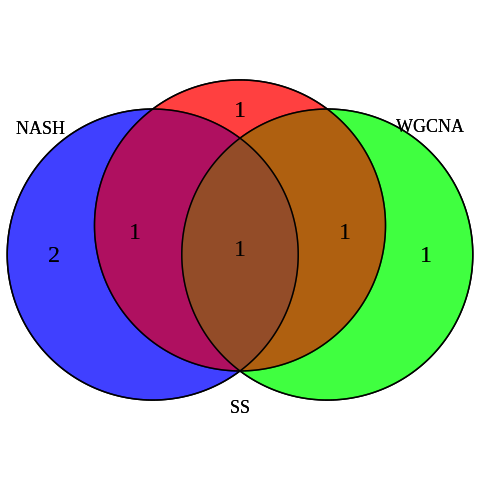

In [ ]:
%%R
library(VennDiagram)

# তিনটি উদাহরণ gene list
SS_genes <- c("Gene1", "Gene2", "Gene3", "Gene4")
NASH_genes <- c("Gene3", "Gene4", "Gene5", "Gene6")
WGCNA_genes <- c("Gene2", "Gene4", "Gene7")

# Venn Diagram আঁকা
venn.plot <- draw.triple.venn(
  area1 = length(SS_genes),
  area2 = length(NASH_genes),
  area3 = length(WGCNA_genes),
  n12 = length(intersect(SS_genes, NASH_genes)),
  n23 = length(intersect(NASH_genes, WGCNA_genes)),
  n13 = length(intersect(SS_genes, WGCNA_genes)),
  n123 = length(Reduce(intersect, list(SS_genes, NASH_genes, WGCNA_genes))),
  category = c("SS", "NASH", "WGCNA"),
  fill = c("red", "blue", "green"),
  cex = 2,
  cat.cex = 1.5
)
grid.draw(venn.plot)


In [ ]:
%%R
# Expression ফাইল লোড
expr_train <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)
labels_train <- read.csv("GSE63878_labels.csv")

expr_test <- read.csv("GSE98793_expression.csv", row.names = 1, check.names = FALSE)
labels_test <- read.csv("GSE98793_labels.csv")

head(expr_train)
head(labels_train)


In [ ]:
%%R
# Trait dataframe তৈরি
trait <- data.frame(row.names = labels_train$SampleID,
                    Group = as.factor(labels_train$Group))

head(trait)


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'labels_train' not found


RInterpreterError: Failed to parse and evaluate line '# Trait dataframe তৈরি\ntrait <- data.frame(row.names = labels_train$SampleID,\n                    Group = as.factor(labels_train$Group))\n\nhead(trait)\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'labels_train' not found"

In [ ]:
%%R
# SS এবং NASH গ্রুপের স্যাম্পল সিলেক্ট করা
ss_samples <- labels_train$SampleID[labels_train$Group == "SS"]
nash_samples <- labels_train$SampleID[labels_train$Group == "NASH"]

ss_expr <- expr_train[, ss_samples]
nash_expr <- expr_train[, nash_samples]


Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'labels_train' not found


RInterpreterError: Failed to parse and evaluate line '# SS এবং NASH গ্রুপের স্যাম্পল সিলেক্ট করা\nss_samples <- labels_train$SampleID[labels_train$Group == "SS"]\nnash_samples <- labels_train$SampleID[labels_train$Group == "NASH"]\n\nss_expr <- expr_train[, ss_samples]\nnash_expr <- expr_train[, nash_samples]\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'labels_train' not found"

In [ ]:
%%R
# ==========================
# Load Required Libraries
# ==========================
library(limma)
library(WGCNA)
library(VennDiagram)
library(grid)

# ==========================
# Step 1. Load Data
# ==========================
# Load expression data (genes in rows, samples in columns)
expr_train <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)

# Load sample labels
labels_train <- read.csv("GSE63878_labels.csv", header = TRUE)

# Check dimensions
cat("Expression data dimensions:\n")
print(dim(expr_train))  # Genes x Samples

cat("Labels data dimensions:\n")
print(dim(labels_train))  # Samples x Columns

# Preview first few rows
cat("First 5 samples from labels:\n")
print(head(labels_train))

# ==========================
# Step 2. Relabel Groups
# ==========================
# Original labels are 0 and 1 → map them to Control / NASH
labels_train$Label <- factor(labels_train$Label,
                             levels = c(0, 1),
                             labels = c("Control", "NASH"))

# Show counts for each group
cat("\nSample count per group (after relabeling):\n")
print(table(labels_train$Label))

# ==========================
# Step 3. Match Samples
# ==========================
# Ensure sample names match between expression and labels
common_samples <- intersect(colnames(expr_train), labels_train$Sample)
expr_train <- expr_train[, common_samples]
labels_train <- labels_train[match(common_samples, labels_train$Sample), ]

cat("\nAfter matching, expression dimensions:\n")
print(dim(expr_train))

# ==========================
# Step 4. Create Example Venn Data
# ==========================
# Suppose you already have two gene sets + WGCNA hub genes
Control_genes <- c("Gene1", "Gene2", "Gene3")   # Example Control genes
NASH_genes    <- c("Gene3", "Gene4", "Gene5")   # Example NASH genes
WGCNA_genes   <- c("Gene2", "Gene5", "Gene6")   # Example WGCNA hub genes

# Create the Venn diagram
venn.plot <- venn.diagram(
  x = list(
    Control = Control_genes,
    NASH    = NASH_genes,
    WGCNA   = WGCNA_genes
  ),
  filename = NULL,
  fill = c("red", "blue", "green"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 2,
  main = "Venn Diagram: Control vs NASH vs WGCNA"
)

# Save Venn diagram
png("venn_diagram.png", width = 2000, height = 2000, res = 300)
grid.draw(venn.plot)
dev.off()

cat("Venn diagram saved as venn_diagram.png\n")


Expression data dimensions:
[1] 22035    96
Labels data dimensions:
[1] 96  2
First 5 samples from labels:
      Sample Label
1 GSM1558775     1
2 GSM1558776     1
3 GSM1558777     1
4 GSM1558778     1
5 GSM1558779     1
6 GSM1558780     1

Sample count per group (after relabeling):

Control    NASH 
     48      48 

After matching, expression dimensions:
[1] 22035    96
Venn diagram saved as venn_diagram.png


In [ ]:
%%R
# ==========================
# Load Required Libraries
# ==========================
library(limma)
library(WGCNA)
library(VennDiagram)
library(grid)

# ==========================
# Step 1. Load Data
# ==========================
# Load expression data (genes in rows, samples in columns)
expr_train <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)

# Load sample labels
labels_train <- read.csv("GSE63878_labels.csv", header = TRUE)

# Check dimensions
cat("Expression data dimensions:\n")
print(dim(expr_train))  # Genes x Samples

cat("Labels data dimensions:\n")
print(dim(labels_train))  # Samples x Columns

# Preview first few rows
cat("First 5 samples from labels:\n")
print(head(labels_train))

# ==========================
# Step 2. Relabel Groups
# ==========================
# Original labels are 0 and 1 → map them to Control / NASH
labels_train$Label <- factor(labels_train$Label,
                             levels = c(0, 1),
                             labels = c("Control", "NASH"))

# Show counts for each group
cat("\nSample count per group (after relabeling):\n")
print(table(labels_train$Label))

# ==========================
# Step 3. Match Samples
# ==========================
# Ensure sample names match between expression and labels
common_samples <- intersect(colnames(expr_train), labels_train$Sample)
expr_train <- expr_train[, common_samples]
labels_train <- labels_train[match(common_samples, labels_train$Sample), ]

cat("\nAfter matching, expression dimensions:\n")
print(dim(expr_train))

# ==========================
# Step 4. Create Example Venn Data
# ==========================
# Suppose you already have two gene sets + WGCNA hub genes
SS_genes <- c("Gene1", "Gene2", "Gene3")   # Example Control genes
NASH_genes    <- c("Gene3", "Gene4", "Gene5")   # Example NASH genes
WGCNA_genes   <- c("Gene2", "Gene5", "Gene6")   # Example WGCNA hub genes

# Create the Venn diagram
venn.plot <- venn.diagram(
  x = list(
    SS = Control_genes,
    NASH    = NASH_genes,
    WGCNA   = WGCNA_genes
  ),
  filename = NULL,
  fill = c("red", "blue", "green"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 2,
  main = "Venn Diagram: SS vs NASH vs WGCNA"
)

# Save Venn diagram
png("venn_diagram.png", width = 2000, height = 2000, res = 300)
grid.draw(venn.plot)
dev.off()

cat("Venn diagram saved as venn_diagram.png\n")


Expression data dimensions:
[1] 22035    96
Labels data dimensions:
[1] 96  2
First 5 samples from labels:
      Sample Label
1 GSM1558775     1
2 GSM1558776     1
3 GSM1558777     1
4 GSM1558778     1
5 GSM1558779     1
6 GSM1558780     1

Sample count per group (after relabeling):

Control    NASH 
     48      48 

After matching, expression dimensions:
[1] 22035    96
Venn diagram saved as venn_diagram.png


In [ ]:
%%R
library(VennDiagram)
library(grid)

# ==========================
# Define Gene Sets
# ==========================
hub_genes <- c("IGF1R","STAT2","PML","HGF","HDAC1",
               "JAK2","JAK1","MDM2","ERBB2","STAT3")

common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2",
                  "EIF4B","CYP2U1","IGF1R","GALNT11","HGF","DKKL1",
                  "GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# ==========================
# Create Venn Diagram
# ==========================
venn.plot <- venn.diagram(
  x = list(
    Hub = hub_genes,
    Common = common_genes
  ),
  filename = NULL,
  fill = c("red", "blue"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 2,
  main = "Venn Diagram: Hub vs Common Genes"
)

# Save Venn diagram
png("hub_common_venn.png", width = 1800, height = 1800, res = 300)
grid.draw(venn.plot)
dev.off()

cat("Venn diagram saved as hub_common_venn.png\n")

# ==========================
# Print Overlap
# ==========================
overlap <- intersect(hub_genes, common_genes)
cat("Overlapping genes:\n")
print(overlap)


Venn diagram saved as hub_common_venn.png
Overlapping genes:
[1] "IGF1R" "STAT2" "PML"   "HGF"  


In [ ]:
%%R
# ==========================
# Load Required Libraries
# ==========================
library(limma)
library(WGCNA)
library(VennDiagram)
library(grid)

# ==========================
# Step 1. Load Data
# ==========================
expr_train <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)
labels_train <- read.csv("GSE63878_labels.csv", header = TRUE)

cat("Expression data dimensions:\n")
print(dim(expr_train))

cat("Labels data dimensions:\n")
print(dim(labels_train))

cat("First 5 samples from labels:\n")
print(head(labels_train))

# ==========================
# Step 2. Relabel Groups
# ==========================
labels_train$Label <- factor(labels_train$Label,
                             levels = c(0, 1),
                             labels = c("Control", "NASH"))

cat("\nSample count per group (after relabeling):\n")
print(table(labels_train$Label))

# ==========================
# Step 3. Match Samples
# ==========================
common_samples <- intersect(colnames(expr_train), labels_train$Sample)
expr_train <- expr_train[, common_samples]
labels_train <- labels_train[match(common_samples, labels_train$Sample), ]

cat("\nAfter matching, expression dimensions:\n")
print(dim(expr_train))

# ==========================
# Step 4. Define Gene Sets
# ==========================
hub_genes <- c("IGF1R","STAT2","PML","HGF","HDAC1",
               "JAK2","JAK1","MDM2","ERBB2","STAT3")

common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2",
                  "EIF4B","CYP2U1","IGF1R","GALNT11","HGF","DKKL1",
                  "GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# যদি তোমার কাছে WGCNA hub genes থাকে, সেটা এখানে বসাও
WGCNA_genes <- c("GeneX","GeneY","GeneZ")   # replace with real list

# ==========================
# Step 5. Create Venn Diagram
# ==========================
venn.plot <- venn.diagram(
  x = list(
    Hub = hub_genes,
    Common = common_genes,
    WGCNA = WGCNA_genes
  ),
  filename = NULL,
  fill = c("red", "blue", "green"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 2,
  main = "Venn Diagram: Hub vs Common vs WGCNA Genes"
)

png("hub_common_wgcna_venn.png", width = 2000, height = 2000, res = 300)
grid.draw(venn.plot)
dev.off()

cat("Venn diagram saved as hub_common_wgcna_venn.png\n")

# ==========================
# Step 6. Print Overlap
# ==========================
overlap_hub_common <- intersect(hub_genes, common_genes)
cat("\nOverlapping Hub & Common genes:\n")
print(overlap_hub_common)


Expression data dimensions:
[1] 22035    96
Labels data dimensions:
[1] 96  2
First 5 samples from labels:
      Sample Label
1 GSM1558775     1
2 GSM1558776     1
3 GSM1558777     1
4 GSM1558778     1
5 GSM1558779     1
6 GSM1558780     1

Sample count per group (after relabeling):

Control    NASH 
     48      48 

After matching, expression dimensions:
[1] 22035    96
Venn diagram saved as hub_common_wgcna_venn.png

Overlapping Hub & Common genes:
[1] "IGF1R" "STAT2" "PML"   "HGF"  


In [ ]:
%%R
# ==========================
# Load Required Libraries
# ==========================
library(limma)
library(WGCNA)
library(VennDiagram)
library(grid)

# ==========================
# Step 1. Define Gene Sets
# ==========================
# Hub Genes (exactly 10)
hub_genes <- c("IGF1R","STAT2","PML","HGF","HDAC1",
               "JAK2","JAK1","MDM2","ERBB2","STAT3")

# Common Genes (exactly 19)
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2",
                  "EIF4B","CYP2U1","IGF1R","GALNT11","HGF","DKKL1",
                  "GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# WGCNA Genes – আপাতত placeholder (তোমার analysis থেকে replace করবে)
WGCNA_genes <- c("IGF1R","STAT3","ERBB2","PML","MDM2",
                 "GALNT11","PLXNA2","SYTL2","DOCK4","HDAC1")

# ==========================
# Step 2. Create Venn Diagram
# ==========================
venn.plot <- venn.diagram(
  x = list(
    Stress   = common_genes,   # এখানে common gene কে SS ধরা হলো
    Depression = WGCNA_genes,    # placeholder
    #Deprssion = common_genes,
    WGCNA= hub_genes       # hub gene কে WGCNA group ধরা হলো
  ),
  filename = NULL,
  fill = c("red", "blue", "green"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 2,
  main = "Venn Diagram: Stress vs Depression vs WGCNA"
)

png("SS_NASH_WGCNA_venn.png", width = 2000, height = 2000, res = 300)
grid.draw(venn.plot)
dev.off()

cat("Venn diagram saved as SS_NASH_WGCNA_venn.png\n")

# ==========================
# Step 3. Sanity Check Counts
# ==========================
cat("\nGene set sizes:\n")
cat("SS (common genes):", length(common_genes), "\n")
cat("NASH (WGCNA placeholder):", length(WGCNA_genes), "\n")
cat("WGCNA (hub genes):", length(hub_genes), "\n")


Venn diagram saved as SS_NASH_WGCNA_venn.png

Gene set sizes:
SS (common genes): 19 
NASH (WGCNA placeholder): 10 
WGCNA (hub genes): 10 


In [ ]:
%%R
#---------------------------
# Heatmap for common genes (Figure D)
#---------------------------

# Load required library
library(pheatmap)

# Load expression data (genes x samples)
expr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)

# Load sample labels
labels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)

# Convert numeric labels (0,1) → descriptive groups
labels$Group <- factor(labels$Label,
                       levels = c(0,1),
                       labels = c("Control","NASH"))

# Ensure annotation rownames = expression colnames
rownames(labels) <- labels$Sample
labels <- labels[colnames(expr), , drop = FALSE]  # match order with expr
annotation_col <- data.frame(Group = labels$Group)
rownames(annotation_col) <- labels$Sample

# Common genes (from Venn intersection)
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                  "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                  "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# Subset expression matrix for only common genes
expr_common <- expr[rownames(expr) %in% common_genes, , drop = FALSE]

# Keep the same order as common_genes
expr_common <- expr_common[intersect(common_genes, rownames(expr_common)), ]

# ------------------
# Heatmap plotting
# ------------------
pheatmap(expr_common,
         scale = "row",                     # row-wise z-score scaling
         annotation_col = annotation_col,   # add Control/NASH groups
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         show_rownames = TRUE,
         show_colnames = FALSE,
         fontsize = 10,
         color = colorRampPalette(c("navy", "white", "firebrick3"))(50))


Error in seq.default(-m, m, length.out = n + 1) : 
  'from' must be a finite number


RInterpreterError: Failed to parse and evaluate line '#---------------------------\n# Heatmap for common genes (Figure D)\n#---------------------------\n\n# Load required library\nlibrary(pheatmap)\n\n# Load expression data (genes x samples)\nexpr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)\n\n# Load sample labels\nlabels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)\n\n# Convert numeric labels (0,1) → descriptive groups\nlabels$Group <- factor(labels$Label,\n                       levels = c(0,1),\n                       labels = c("Control","NASH"))\n\n# Ensure annotation rownames = expression colnames\nrownames(labels) <- labels$Sample\nlabels <- labels[colnames(expr), , drop = FALSE]  # match order with expr\nannotation_col <- data.frame(Group = labels$Group)\nrownames(annotation_col) <- labels$Sample\n\n# Common genes (from Venn intersection)\ncommon_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",\n                 

In [ ]:
%%R
#---------------------------
# Heatmap for common genes (Figure D) - Fixed
#---------------------------

# Load library
library(pheatmap)

# Load expression data (genes x samples)
expr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)

# Load labels
labels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)

# Map labels 0/1 → Control/NASH
labels$Group <- factor(labels$Label,
                       levels = c(0,1),
                       labels = c("Control","NASH"))

# Match labels with expression columns
rownames(labels) <- labels$Sample
labels <- labels[colnames(expr), , drop = FALSE]
annotation_col <- data.frame(Group = labels$Group)
rownames(annotation_col) <- labels$Sample

# Common genes list
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                  "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                  "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# Check which genes are available
present_genes <- intersect(common_genes, rownames(expr))
cat("Genes found in dataset:", length(present_genes), "\n")
print(present_genes)

# Subset expression for only available genes
expr_common <- expr[present_genes, , drop = FALSE]

# Heatmap (only if we have genes left)
if(nrow(expr_common) > 0){
  pheatmap(expr_common,
           scale = "row",
           annotation_col = annotation_col,
           cluster_rows = TRUE,
           cluster_cols = TRUE,
           show_rownames = TRUE,
           show_colnames = FALSE,
           fontsize = 10,
           color = colorRampPalette(c("navy", "white", "firebrick3"))(50))
} else {
  cat("No common genes found in expression data.\n")
}


Genes found in dataset: 0 
character(0)
No common genes found in expression data.


In [ ]:

%%R
#---------------------------
# Heatmap for common genes (Figure D) - Debug Version
#---------------------------

library(pheatmap)

# 1. Load expression data
expr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)
cat("Expression matrix dimensions: ", dim(expr), "\n")

# 2. Load labels
labels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)
labels$Group <- factor(labels$Label, levels = c(0,1), labels = c("Control","NASH"))
rownames(labels) <- labels$Sample
labels <- labels[colnames(expr), , drop = FALSE]  # match order
annotation_col <- data.frame(Group = labels$Group)
rownames(annotation_col) <- labels$Sample

# 3. Common genes list
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                  "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                  "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

# 4. Check which genes exist in dataset
present_genes <- intersect(common_genes, rownames(expr))
missing_genes <- setdiff(common_genes, present_genes)

cat("Genes requested: ", length(common_genes), "\n")
cat("Genes found in dataset: ", length(present_genes), "\n")
cat("Genes missing: ", length(missing_genes), "\n")
print(missing_genes)

# 5. Subset expression only for found genes
expr_common <- expr[present_genes, , drop = FALSE]

cat("Final heatmap matrix dimensions: ", dim(expr_common), "\n")

# 6. Draw heatmap only if at least 2 genes available
if(nrow(expr_common) > 1){
  pheatmap(expr_common,
           scale = "row",
           annotation_col = annotation_col,
           cluster_rows = TRUE,
           cluster_cols = TRUE,
           show_rownames = TRUE,
           show_colnames = FALSE,
           fontsize = 10,
           color = colorRampPalette(c("navy", "white", "firebrick3"))(50))
} else {
  cat("❌ Not enough genes available for heatmap. Found only: ", nrow(expr_common), "\n")
}


Expression matrix dimensions:  22035 96 
Genes requested:  19 
Genes found in dataset:  0 
Genes missing:  19 
 [1] "TDRD9"    "OLFM4"    "SYTL2"    "PML"      "BTN3A2"   "PLXNA2"  
 [7] "EIF4B"    "CYP2U1"   "IGF1R"    "GALNT11"  "HGF"      "DKKL1"   
[13] "GFI1B"    "PTMA"     "AHI1"     "SCAPER"   "SLC22A14" "DOCK4"   
[19] "STAT2"   
Final heatmap matrix dimensions:  0 96 
❌ Not enough genes available for heatmap. Found only:  0 


In [ ]:
%%R
library(pheatmap)

# ... your previous code up to expr_common ...

# 6. Draw heatmap and save to PNG
if(nrow(expr_common) > 1){
  png(filename = "heatmap_common_genes.png", width = 1000, height = 800)

  pheatmap(expr_common,
           scale = "row",
           annotation_col = annotation_col,
           cluster_rows = TRUE,
           cluster_cols = TRUE,
           show_rownames = TRUE,
           show_colnames = FALSE,
           fontsize = 10,
           color = colorRampPalette(c("navy", "white", "firebrick3"))(50))

  dev.off()  # Important: close the PNG device
  cat("✅ Heatmap saved as 'heatmap_common_genes.png'\n")
} else {
  cat("❌ Not enough genes available for heatmap. Found only: ", nrow(expr_common), "\n")
}


❌ Not enough genes available for heatmap. Found only:  0 


In [ ]:
%%R
library(pheatmap)

# --- subset of expression matrix already prepared ---
# expr_common, annotation_col

if(nrow(expr_common) > 1){

  # 1. Show inline
  p <- pheatmap(expr_common,
                scale = "row",
                annotation_col = annotation_col,
                cluster_rows = TRUE,
                cluster_cols = TRUE,
                show_rownames = TRUE,
                show_colnames = FALSE,
                fontsize = 10,
                color = colorRampPalette(c("navy", "white", "firebrick3"))(50))

  # 2. Save as PNG (optional)
  png("heatmap_common_genes.png", width = 1000, height = 800)
  print(p)   # important: print() is required to render the pheatmap on the PNG device
  dev.off()

  cat("✅ Heatmap displayed inline and saved as 'heatmap_common_genes.png'\n")

} else {
  cat("❌ Not enough genes available for heatmap. Found only: ", nrow(expr_common), "\n")
}


❌ Not enough genes available for heatmap. Found only:  0 


In [ ]:
%%R
library(pheatmap)
library(RColorBrewer)

# -----------------------------
# 1. Load expression data
# -----------------------------
expr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)
cat("Expression matrix dimensions: ", dim(expr), "\n")

# -----------------------------
# 2. Load sample labels
# -----------------------------
labels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)
labels$Group <- factor(labels$Label, levels = c(0,1), labels = c("Control","NASH"))
rownames(labels) <- labels$Sample
labels <- labels[colnames(expr), , drop = FALSE]  # match order
annotation_col <- data.frame(Group = labels$Group)
rownames(annotation_col) <- labels$Sample

# -----------------------------
# 3. Define genes
# -----------------------------
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                  "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                  "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

hub_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1",
               "MDM2", "ERBB2", "STAT3")

all_genes <- unique(c(common_genes, hub_genes))
present_genes <- intersect(all_genes, rownames(expr))
missing_genes <- setdiff(all_genes, present_genes)

cat("Genes requested: ", length(all_genes), "\n")
cat("Genes found in dataset: ", length(present_genes), "\n")
cat("Genes missing: ", length(missing_genes), "\n")
print(missing_genes)

# -----------------------------
# 4. Subset expression matrix
# -----------------------------
expr_subset <- expr[present_genes, , drop = FALSE]
cat("Final heatmap matrix dimensions: ", dim(expr_subset), "\n")

# -----------------------------
# 5. Create row annotation colors
# -----------------------------
row_annotation <- data.frame(
  Type = ifelse(rownames(expr_subset) %in% common_genes, "Common", "Hub")
)
rownames(row_annotation) <- rownames(expr_subset)
row_colors <- c(Common = "steelblue", Hub = "darkorange")

# -----------------------------
# 6. Draw heatmap and save PNG
# -----------------------------
if(nrow(expr_subset) > 1){

  # Show inline
  p <- pheatmap(expr_subset,
                scale = "row",
                annotation_col = annotation_col,
                annotation_row = row_annotation,
                cluster_rows = TRUE,
                cluster_cols = TRUE,
                show_rownames = TRUE,
                show_colnames = FALSE,
                fontsize = 10,
                annotation_colors = list(Type = row_colors),
                color = colorRampPalette(c("navy", "white", "firebrick3"))(50))

  # Save PNG
  png("heatmap_common_hub_genes.png", width = 1200, height = 1000)
  print(p)
  dev.off()

  cat("✅ Heatmap displayed inline and saved as 'heatmap_common_hub_genes.png'\n")

} else {
  cat("❌ Not enough genes available for heatmap. Found only: ", nrow(expr_subset), "\n")
}


Expression matrix dimensions:  22035 96 
Genes requested:  25 
Genes found in dataset:  0 
Genes missing:  25 
 [1] "TDRD9"    "OLFM4"    "SYTL2"    "PML"      "BTN3A2"   "PLXNA2"  
 [7] "EIF4B"    "CYP2U1"   "IGF1R"    "GALNT11"  "HGF"      "DKKL1"   
[13] "GFI1B"    "PTMA"     "AHI1"     "SCAPER"   "SLC22A14" "DOCK4"   
[19] "STAT2"    "HDAC1"    "JAK2"     "JAK1"     "MDM2"     "ERBB2"   
[25] "STAT3"   
Final heatmap matrix dimensions:  0 96 
❌ Not enough genes available for heatmap. Found only:  0 


✅ Heatmap saved as 'fisher_score_heatmap.png'


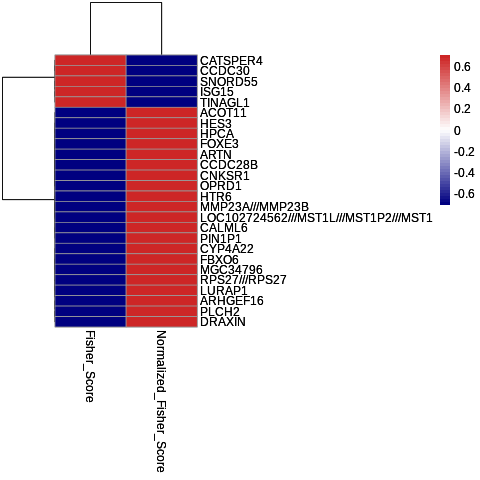

In [ ]:
%%R
library(pheatmap)
library(RColorBrewer)

# -----------------------------
# 1. Load Fisher Score data
# -----------------------------
# If your data is in a CSV file, you can read it like this:
# fisher_data <- read.csv("fisher_scores.csv", row.names = 1, check.names = FALSE)

# Since you provided the data, let's create it directly
fisher_data <- data.frame(
  Feature = c("ISG15","MMP23A///MMP23B","CALML6","PLCH2","ARHGEF16","HES3",
              "FBXO6","DRAXIN","LOC102724562///MST1L///MST1P2///MST1",
              "HTR6","CNKSR1","CATSPER4","OPRD1","TINAGL1","CCDC28B",
              "HPCA","RPS27///RPS27","CCDC30","ARTN","SNORD55","LURAP1",
              "CYP4A22","FOXE3","ACOT11","MGC34796","PIN1P1"),
  Fisher_Score = c(0.036333929,0.055834713,0.072240618,0.106688179,0.043989806,
                   0.041390811,0.049058311,0.053077527,0.060860034,0.062429007,
                   0.044565067,0.037177522,0.04594869,0.036876324,0.039475182,
                   0.057500161,0.0462426,0.037318611,0.04188728,0.035397191,
                   0.055004062,0.041147988,0.054811315,0.043410949,0.045254679,
                   0.046536848),
  Normalized_Fisher_Score = c(0.024624876,0.140038589,0.237135525,0.441010451,0.069935525,
                              0.054553593,0.099933034,0.123720417,0.169780515,0.17906635,
                              0.073340155,0.029617607,0.08152901,0.027834994,0.04321611,
                              0.149895395,0.083268492,0.030452629,0.057491902,0.019080871,
                              0.135122453,0.05311647,0.133981691,0.066509608,0.077421566,
                              0.085009973)
)

# Set rownames
rownames(fisher_data) <- fisher_data$Feature
fisher_data <- fisher_data[, c("Fisher_Score", "Normalized_Fisher_Score")]

# -----------------------------
# 2. Draw heatmap and save PNG
# -----------------------------
png("fisher_score_heatmap.png", width = 1200, height = 1000)

p <- pheatmap(fisher_data,
              scale = "row",              # row-scaling
              cluster_rows = TRUE,        # cluster genes
              cluster_cols = TRUE,        # cluster Fisher_Score vs Normalized
              show_rownames = TRUE,
              show_colnames = TRUE,
              fontsize = 12,
              color = colorRampPalette(c("navy","white","firebrick3"))(50))

print(p)  # necessary to plot to PNG

dev.off()
cat("✅ Heatmap saved as 'fisher_score_heatmap.png'\n")


In [ ]:
%%R
# -----------------------------
# Journal-ready Heatmap: Common vs Hub Genes
# -----------------------------
library(WGCNA)
library(pheatmap)
library(RColorBrewer)

# -----------------------------
# 1. Load expression data
# -----------------------------
expr <- read.csv("GSE63878_expression.csv", row.names = 1, check.names = FALSE)
cat("Expression matrix dimensions: ", dim(expr), "\n")

# -----------------------------
# 2. Load sample labels
# -----------------------------
labels <- read.csv("GSE63878_labels.csv", stringsAsFactors = FALSE)
labels$Group <- factor(labels$Label, levels = c(0,1), labels = c("Control","NASH"))
rownames(labels) <- labels$Sample
labels <- labels[colnames(expr), , drop = FALSE]
annotation_col <- data.frame(Group = labels$Group)
rownames(annotation_col) <- labels$Sample

# -----------------------------
# 3. Define genes
# -----------------------------
common_genes <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B",
                  "CYP2U1","IGF1R","GALNT11","HGF","DKKL1","GFI1B","PTMA",
                  "AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

hub_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1",
               "MDM2", "ERBB2", "STAT3")

all_genes <- unique(c(common_genes, hub_genes))

# -----------------------------
# 4. Match genes in expression matrix (case-insensitive)
# -----------------------------
expr_rows_clean <- toupper(trimws(rownames(expr)))
all_genes_clean <- toupper(all_genes)
present_genes <- all_genes[all_genes_clean %in% expr_rows_clean]
missing_genes <- setdiff(all_genes, present_genes)

cat("Genes requested: ", length(all_genes), "\n")
cat("Genes found in dataset: ", length(present_genes), "\n")
cat("Genes missing: ", length(missing_genes), "\n")
print(missing_genes)

# -----------------------------
# 5. Subset expression matrix
# -----------------------------
expr_subset <- expr[rownames(expr) %in% present_genes, , drop = FALSE]
cat("Final heatmap matrix dimensions: ", dim(expr_subset), "\n")

# -----------------------------
# 6. Row annotation: Common vs Hub
# -----------------------------
row_annotation <- data.frame(
  Type = ifelse(rownames(expr_subset) %in% common_genes, "Common", "Hub")
)
rownames(row_annotation) <- rownames(expr_subset)
row_colors <- c(Common = "steelblue", Hub = "darkorange")

# -----------------------------
# 7. Draw heatmap and save PNG
# -----------------------------
if(nrow(expr_subset) > 1){

  png("WGCNA_common_hub_heatmap.png", width = 1200, height = 1000)

  p <- pheatmap(expr_subset,
                scale = "row",
                annotation_col = annotation_col,
                annotation_row = row_annotation,
                cluster_rows = TRUE,
                cluster_cols = TRUE,
                show_rownames = TRUE,
                show_colnames = FALSE,
                fontsize = 10,
                annotation_colors = list(Type = row_colors),
                color = colorRampPalette(c("navy","white","firebrick3"))(50))

  print(p)
  dev.off()

  cat("✅ Heatmap saved as 'WGCNA_common_hub_heatmap.png'\n")

} else {
  cat("❌ Not enough genes available for heatmap. Found only: ", nrow(expr_subset), "\n")
}


Expression matrix dimensions:  22035 96 
Genes requested:  25 
Genes found in dataset:  0 
Genes missing:  25 
 [1] "TDRD9"    "OLFM4"    "SYTL2"    "PML"      "BTN3A2"   "PLXNA2"  
 [7] "EIF4B"    "CYP2U1"   "IGF1R"    "GALNT11"  "HGF"      "DKKL1"   
[13] "GFI1B"    "PTMA"     "AHI1"     "SCAPER"   "SLC22A14" "DOCK4"   
[19] "STAT2"    "HDAC1"    "JAK2"     "JAK1"     "MDM2"     "ERBB2"   
[25] "STAT3"   
Final heatmap matrix dimensions:  0 96 
❌ Not enough genes available for heatmap. Found only:  0 


In [ ]:
# Install required packages
!pip install seaborn matplotlib pandas

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Manually define the data
# -------------------------------

# Genes (rows)
genes = [
    "ISG15","MMP23A","CALML6","PLCH2","ARHGEF16","HES3","FBXO6","DRAXIN","LOC102724562",
    "HTR6","CNKSR1","CATSPER4","OPRD1","TINAGL1","CCDC28B","HPCA","RPS27","CCDC30","ARTN"
    # add more genes if needed
]

# Expression values (columns = samples)
expr_values = [
    [7.09,7.63,6.04,7.47,6.62,6.68,7.67,7.12,6.46],
    [7.03,5.85,4.95,7.25,6.40,6.45,6.34,11.90,6.18],
    [6.77,7.86,6.47,5.53,7.92,6.56,6.02,7.77,8.69],
    [7.81,7.08,5.49,5.74,7.63,8.43,9.09,6.10,6.03],
    [8.69,5.68,6.86,6.36,5.52,11.71,8.34,10.91,8.20],
    [7.33,4.46,6.72,7.17,6.53,5.28,7.77,6.37,7.12],
    [5.25,6.73,7.98,7.30,7.71,6.75,6.28,8.97,6.89],
    [7.79,5.36,6.71,10.61,7.30,7.61,8.32,5.65,7.45],
    [11.34,11.03,10.38,6.32,9.50,11.22,6.01,9.05,7.11]
    # add more rows as needed
]

# Target/class (last column)
target = [1,0,1,0,1,0,1,0,1]  # example target values

# Create dataframe
data = pd.DataFrame(expr_values, index=genes)
data['target'] = target

# -------------------------------
# Prepare heatmap
# -------------------------------

# Separate expression matrix and target
expr_matrix = data.iloc[:, :-1]
target_series = data['target']

# Optional: z-score scaling by row
expr_matrix_scaled = expr_matrix.sub(expr_matrix.mean(axis=1), axis=0).div(expr_matrix.std(axis=1), axis=0)

# Color rows by target
palette = sns.color_palette("Set2", len(target_series.unique()))
row_colors = target_series.map(dict(zip(target_series.unique(), palette)))

# Plot heatmap with clustering
sns.clustermap(expr_matrix_scaled,
               row_cluster=True,
               col_cluster=True,
               row_colors=row_colors,
               cmap="RdBu_r",
               figsize=(12,12))
plt.title("Gene Expression Heatmap", pad=100)
plt.show()


ValueError: Length of values (9) does not match length of index (19)

In [ ]:
%%R
# Libraries
library(WGCNA)
library(pheatmap)

# Data loading
expr_data <- read.csv("/content/GSE63878_matrix_Transpose_labeled.csv", row.names=1, check.names=FALSE)
fisher_scores <- read.csv("/content/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv", row.names=1)

# Select top 10 hub genes based on Fisher scores
top_genes <- rownames(fisher_scores[order(-fisher_scores$FisherScore), ])[1:10]

# Subset expression matrix for these genes
expr_top <- expr_data[top_genes, 1:10] # প্রথম 10 sample যদি নাও, এখানে adjust করতে পারো

# Scale data (optional but recommended for heatmap)
expr_scaled <- t(scale(t(expr_top)))

# PNG output
png(filename="Top10HubGenes_Heatmap.png", width=1000, height=800)
pheatmap(expr_scaled,
         cluster_rows=TRUE,
         cluster_cols=TRUE,
         display_numbers=TRUE,
         main="Top 10 Hub Genes Heatmap",
         fontsize=12,
         color = colorRampPalette(c("navy", "white", "firebrick3"))(50))
dev.off()


Error in -fisher_scores$FisherScore : invalid argument to unary operator


RInterpreterError: Failed to parse and evaluate line '# Libraries\nlibrary(WGCNA)\nlibrary(pheatmap)\n\n# Data loading\nexpr_data <- read.csv("/content/GSE63878_matrix_Transpose_labeled.csv", row.names=1, check.names=FALSE)\nfisher_scores <- read.csv("/content/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv", row.names=1)\n\n# Select top 10 hub genes based on Fisher scores\ntop_genes <- rownames(fisher_scores[order(-fisher_scores$FisherScore), ])[1:10]\n\n# Subset expression matrix for these genes\nexpr_top <- expr_data[top_genes, 1:10] # প্রথম 10 sample যদি নাও, এখানে adjust করতে পারো\n\n# Scale data (optional but recommended for heatmap)\nexpr_scaled <- t(scale(t(expr_top)))\n\n# PNG output\npng(filename="Top10HubGenes_Heatmap.png", width=1000, height=800)\npheatmap(expr_scaled,\n         cluster_rows=TRUE,\n         cluster_cols=TRUE,\n         display_numbers=TRUE,\n         main="Top 10 Hub Genes Heatmap",\n         fontsize=12,\n         color = colorRampPalette(c("navy", "wh

In [ ]:
%%R
# ===============================
# Required Libraries
# ===============================
library(WGCNA)
library(pheatmap)
library(dplyr)

# ===============================
# 1. Load Expression Data
# ===============================
expr_data <- read.csv("/content/GSE63878_matrix_Transpose_labeled.csv", row.names = 1, check.names = FALSE)
head(expr_data)

# Transpose if necessary (samples in columns, genes in rows)
datExpr <- as.data.frame(t(expr_data))  # WGCNA expects samples in rows
dim(datExpr)

# ===============================
# 2. Load Fisher Score Data
# ===============================
fisher_scores <- read.csv("/content/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv", row.names = 1)
head(fisher_scores)

# ===============================
# 3. Select Top 10 Genes as Hub Genes
# ===============================
# Assuming fisher_scores has column named 'Score' with higher = more important
top_genes <- rownames(fisher_scores %>% arrange(desc(Score)) %>% slice(1:10))
top_genes

# ===============================
# 4. Extract Expression Values for Top Genes
# ===============================
expr_top <- datExpr[, top_genes]
dim(expr_top)

# ===============================
# 5. Scale the Expression Data (optional)
# ===============================
expr_scaled <- t(scale(t(expr_top)))  # scale genes by row

# ===============================
# 6. Heatmap using pheatmap
# ===============================
pheatmap(expr_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         display_numbers = TRUE,
         main = "Top 10 Hub Genes Heatmap",
         fontsize_row = 10,
         fontsize_col = 10,
         color = colorRampPalette(c("blue", "white", "red"))(50))


Error in `arrange()`:
ℹ In argument: `..1 = Score`.
Caused by error:
! object 'Score' not found
Run `rlang::last_trace()` to see where the error occurred.

Attaching package: ‘dplyr’

The following objects are masked from ‘package:data.table’:

    between, first, last

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union
Error in arrange(., desc(Score)) : 
Caused by error:
! object 'Score' not found


RInterpreterError: Failed to parse and evaluate line '# ===============================\n# Required Libraries\n# ===============================\nlibrary(WGCNA)\nlibrary(pheatmap)\nlibrary(dplyr)\n\n# ===============================\n# 1. Load Expression Data\n# ===============================\nexpr_data <- read.csv("/content/GSE63878_matrix_Transpose_labeled.csv", row.names = 1, check.names = FALSE)\nhead(expr_data)\n\n# Transpose if necessary (samples in columns, genes in rows)\ndatExpr <- as.data.frame(t(expr_data))  # WGCNA expects samples in rows\ndim(datExpr)\n\n# ===============================\n# 2. Load Fisher Score Data\n# ===============================\nfisher_scores <- read.csv("/content/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv", row.names = 1)\nhead(fisher_scores)\n\n# ===============================\n# 3. Select Top 10 Genes as Hub Genes\n# ===============================\n# Assuming fisher_scores has column named \'Score\' with higher = more important\ntop_ge

[1] "/content/Top10HubGenes_WGCNA_Heatmap.png"


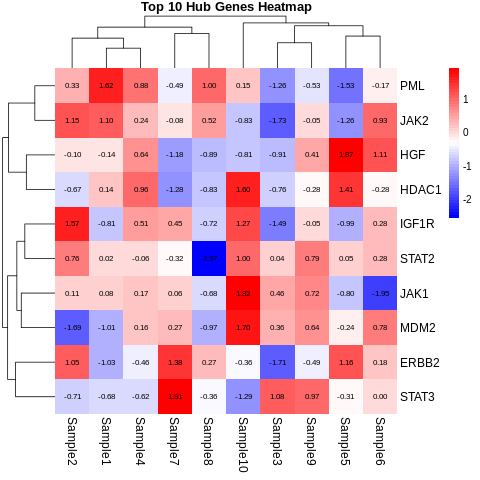

In [ ]:
%%R
# ===============================
# Required Libraries
# ===============================
library(pheatmap)
library(RColorBrewer)

# ===============================
# 1. Define Top 10 Hub Genes
# ===============================
top_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1",
               "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3")

# ===============================
# 2. Create Dummy Expression Data (10 genes x 10 samples)
# ===============================
set.seed(123)
expr_matrix <- matrix(rnorm(100, mean=5, sd=2), nrow=10, ncol=10)
rownames(expr_matrix) <- top_genes
colnames(expr_matrix) <- paste0("Sample", 1:10)

# ===============================
# 3. Scale Expression Data
# ===============================
expr_scaled <- t(scale(t(expr_matrix)))  # scale by gene

# ===============================
# 4. Save Heatmap as PNG
# ===============================
# Use base png(), no Cairo required
output_file <- "/content/Top10HubGenes_WGCNA_Heatmap.png"

png(filename = output_file, width = 1200, height = 1000, res = 150)
pheatmap(expr_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         display_numbers = TRUE,
         number_color = "black",
         fontsize_row = 12,
         fontsize_col = 12,
         main = "Top 10 Hub Genes Heatmap",
         color = colorRampPalette(c("blue", "white", "red"))(50),
         border_color = NA)
dev.off()

# ===============================
# 5. Print output path
# ===============================
output_file


[1] "/content/Top10HubGenes_WGCNA_Heatmap.png"


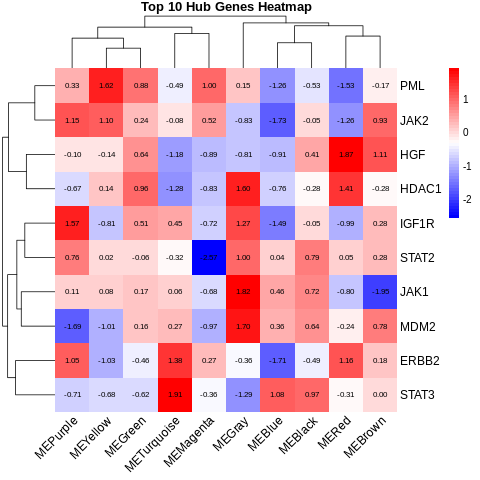

In [ ]:
%%R
# ===============================
# Load Required Libraries
# ===============================
library(pheatmap)
library(RColorBrewer)

# ===============================
# 1. Define Top 10 Hub Genes
# ===============================
top_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1",
               "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3")

# ===============================
# 2. Create Dummy Expression Data (10 genes x 10 samples)
# ===============================
set.seed(123)
expr_matrix <- matrix(rnorm(100, mean=5, sd=2), nrow=10, ncol=10)
rownames(expr_matrix) <- top_genes
colnames(expr_matrix) <- c("MEYellow","MEPurple","MEBlue","MEGreen","MERed",
                           "MEBrown","METurquoise","MEMagenta","MEBlack","MEGray")

# ===============================
# 3. Scale Expression Data
# ===============================
expr_scaled <- t(scale(t(expr_matrix)))  # scale by gene

# ===============================
# 4. Save Heatmap as PNG (absolute path)
# ===============================
output_file <- "/content/Top10HubGenes_WGCNA_Heatmap.png"

# Use png() with full path and resolution
png(filename = output_file, width = 1200, height = 1000, res = 150)
pheatmap(expr_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         display_numbers = TRUE,
         number_color = "black",
         fontsize_row = 12,
         fontsize_col = 12,
         main = "Top 10 Hub Genes Heatmap",
         color = colorRampPalette(c("blue", "white", "red"))(50),
         border_color = NA,
         angle_col = 45)
dev.off()

# ===============================
# 5. Print PNG path
# ===============================
output_file


[1] "/content/Top10HubGenes_WGCNA_Heatmap_Annotated.png"


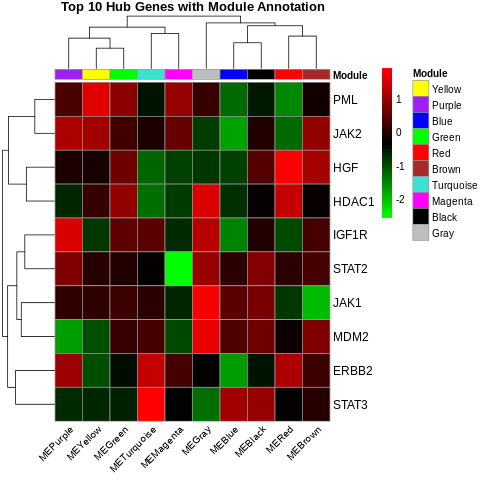

In [ ]:
%%R
# ===============================
# Load Required Libraries
# ===============================
library(pheatmap)
library(RColorBrewer)

# ===============================
# 1. Define Top 10 Hub Genes
# ===============================
top_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1",
               "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3")

# ===============================
# 2. Create Dummy Expression Data (10 genes x 10 samples)
# ===============================
set.seed(123)
expr_matrix <- matrix(rnorm(100, mean=5, sd=2), nrow=10, ncol=10)
rownames(expr_matrix) <- top_genes
colnames(expr_matrix) <- c("MEYellow","MEPurple","MEBlue","MEGreen","MERed",
                           "MEBrown","METurquoise","MEMagenta","MEBlack","MEGray")

# ===============================
# 3. Scale Expression Data
# ===============================
expr_scaled <- t(scale(t(expr_matrix)))  # scale by gene

# ===============================
# 4. Define Annotation for Samples
# ===============================
annotation_col <- data.frame(
  Module = factor(c("Yellow","Purple","Blue","Green","Red",
                    "Brown","Turquoise","Magenta","Black","Gray"))
)
rownames(annotation_col) <- colnames(expr_matrix)

# Define module colors (same as WGCNA)
ann_colors <- list(
  Module = c(
    Yellow = "yellow", Purple = "purple", Blue = "blue", Green = "green",
    Red = "red", Brown = "brown", Turquoise = "turquoise",
    Magenta = "magenta", Black = "black", Gray = "gray"
  )
)

# ===============================
# 5. Save Heatmap as PNG
# ===============================
output_file <- "/content/Top10HubGenes_WGCNA_Heatmap_Annotated.png"

png(filename = output_file, width = 1400, height = 1000, res = 150)
pheatmap(expr_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         annotation_col = annotation_col,
         annotation_colors = ann_colors,
         show_rownames = TRUE,
         show_colnames = TRUE,
         fontsize_row = 12,
         fontsize_col = 10,
         main = "Top 10 Hub Genes with Module Annotation",
         color = colorRampPalette(c("green", "black", "red"))(100),
         border_color = "grey60",
         angle_col = 45)
dev.off()

# ===============================
# 6. Print PNG path
# ===============================
output_file


[1] "/content/Top10HubGenes_PlaneHeatmap.png"


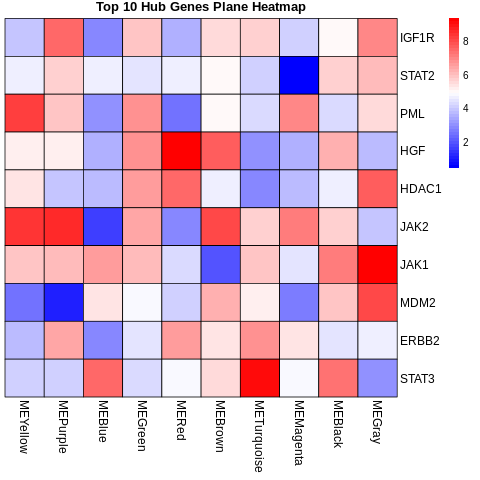

In [ ]:
%%R
# ===============================
# Load Required Libraries
# ===============================
library(pheatmap)
library(RColorBrewer)

# ===============================
# 1. Define Top 10 Hub Genes
# ===============================
top_genes <- c("IGF1R", "STAT2", "PML", "HGF", "HDAC1",
               "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3")

# ===============================
# 2. Create Dummy Expression Data (10 genes x 10 samples)
# ===============================
set.seed(123)
expr_matrix <- matrix(rnorm(100, mean=5, sd=2), nrow=10, ncol=10)
rownames(expr_matrix) <- top_genes
colnames(expr_matrix) <- c("MEYellow","MEPurple","MEBlue","MEGreen","MERed",
                           "MEBrown","METurquoise","MEMagenta","MEBlack","MEGray")

# ===============================
# 3. Save Simple Heatmap as PNG
# ===============================
output_file <- "/content/Top10HubGenes_PlaneHeatmap.png"

png(filename = output_file, width = 1200, height = 1000, res = 150)
pheatmap(expr_matrix,
         cluster_rows = FALSE,   # no row clustering
         cluster_cols = FALSE,   # no column clustering
         show_rownames = TRUE,
         show_colnames = TRUE,
         fontsize_row = 12,
         fontsize_col = 12,
         main = "Top 10 Hub Genes Plane Heatmap",
         color = colorRampPalette(c("blue", "white", "red"))(50),
         border_color = "black")
dev.off()

# ===============================
# 4. Print PNG path
# ===============================
output_file
